# Case SENTINEL — Stage 2: Deep-Dive Reassessment under Enforcement Scrutiny
**DECODE X | NLD Synapse 2026 | 28 February 2026**

Pipeline: Validation Data Load → Stage 1 Baseline Re-establish → False Positive Identification → Missed Cluster Detection → Mechanism Differentiation (Circular / Pump & Dump / Legitimate HFT) → Revised Risk Scoring → Consolidated Verdicts

---
**Enforcement Assumptions:**
- At least one previously flagged cluster is **legitimate activity** (false positive)
- At least one under-flagged cluster represents **coordinated manipulation** (missed)
- Suspect lists are **incomplete by design**

**Mechanism Differentiation Target:**

| Pattern | Structural Indicator |
|---|---|
| Circular Trading | Closed loops without economic rationale; persistent across dates |
| Pump & Dump | Coordinated volume surge + intra-day price amplitude |
| Legitimate HFT | High turnover, low reciprocity per partner, no persistent loops |

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import glob
import os
import re
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from itertools import combinations
from collections import defaultdict

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('future.no_silent_downcasting', True)
sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')

# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────
SENTINEL_BASE    = r'E:\Synapse-BI\04 – Case SENTINEL'
TRADES_CSV       = os.path.join(SENTINEL_BASE, 'master_trades_combined.csv')
SUSPECT_TRD_DIR  = os.path.join(SENTINEL_BASE, 'Suspicious list', 'Trades')
SUSPECT_ORD_DIR  = os.path.join(SENTINEL_BASE, 'Suspicious list', 'Orders')
VAL_TRADES_DIR   = os.path.join(SENTINEL_BASE, 'Validation Set', 'Trades')
VAL_ORDERS_DIR   = os.path.join(SENTINEL_BASE, 'Validation Set', 'Orders')
ORDERS_XLS_DIR   = os.path.join(SENTINEL_BASE, 'Orders')
CHARTS_DIR       = r'E:\Synapse-BI\sentinel_charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS & PALETTES
# ─────────────────────────────────────────────────────────────────────────────
PUMP_THRESHOLD        = 5.0    # % intra-day amplitude → Pump & Dump
LOOP_MIN_VOLUME       = 500
LOOP_MAX_LENGTH       = 3
HFT_TRADES_PER_DAY    = 20     # ≥ threshold → candidate for HFT
HFT_MIN_COUNTERPARTS  = 8      # ≥ threshold unique CPs per session → HFT
HFT_LOOP_PERSIST_DAYS = 2      # > threshold days with same loop group → Circular (not HFT)
SYNC_GAP_SEC          = 60     # avg inter-trade gap < this → real-time sync

MECH_CLR = {
    'Circular Trading'                      : '#2A9D8F',
    'Pump & Dump'                           : '#E63946',
    'Infrastructure-Linked Pump & Dump'     : '#9B2335',
    'Infrastructure-Linked'                 : '#457B9D',
    'Legitimate HFT'                        : '#52B788',
    'Ambiguous'                             : '#888888',
}
SEVERITY = {
    'Infrastructure-Linked Pump & Dump': 5,
    'Pump & Dump'                       : 4,
    'Circular Trading'                  : 3,
    'Infrastructure-Linked'             : 2,
    'Legitimate HFT'                    : 0,
}
TIER_CLR = {'LOW':'#2A9D8F','MEDIUM':'#E9C46A','HIGH':'#F4A261','CRITICAL':'#E63946'}
MONTH_MAP = {
    'jan':'JAN','feb':'FEB','mar':'MAR','apr':'APR','may':'MAY','jun':'JUN',
    'jul':'JUL','july':'JUL','aug':'AUG','sep':'SEP','oct':'OCT','nov':'NOV','dec':'DEC',
}

print('Stage 2 environment initialised.')
print(f'Validation Trades dir : {VAL_TRADES_DIR}')
print(f'Validation Orders dir : {VAL_ORDERS_DIR}')

Stage 2 environment initialised.
Validation Trades dir : E:\Synapse-BI\04 – Case SENTINEL\Validation Set\Trades
Validation Orders dir : E:\Synapse-BI\04 – Case SENTINEL\Validation Set\Orders


## Step 1 — Reload Stage 1 Baseline (Master Trades + Suspects)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 1A — Master trade tape
# ─────────────────────────────────────────────────────────────────────────────
df_s1 = pd.read_csv(TRADES_CSV, low_memory=False)
if 'Sell Client code' in df_s1.columns:
    df_s1['Sell Client Code'] = df_s1['Sell Client Code'].fillna(df_s1['Sell Client code'])
df_s1.drop(columns=[c for c in ['Sell Client code','Buy Timestamp','Sell Timestamp']
                    if c in df_s1.columns], inplace=True)
for col in ['SCRIP_CODE','Buy Client Code','Sell Client Code',
            'BUY_MEMBER_CODE','SELL_MEMBER_CODE']:
    df_s1[col] = df_s1[col].astype(str).str.strip()
df_s1['TRADE_TIME_DT'] = pd.to_datetime(df_s1['TRADE_TIME'], errors='coerce', format='mixed')

# ─────────────────────────────────────────────────────────────────────────────
# 1B — Stage 1 suspect list (trades)
# ─────────────────────────────────────────────────────────────────────────────
_sus_raw = []
for f in glob.glob(os.path.join(SUSPECT_TRD_DIR, '*.csv')):
    try:
        tmp = pd.read_csv(f)
        if not tmp.empty:
            _sus_raw.append(tmp)
    except Exception:
        pass
suspects_s1 = pd.concat(_sus_raw, ignore_index=True)
suspects_s1.columns = suspects_s1.columns.str.strip()
suspects_s1['client_id']  = suspects_s1['client_id'].astype(str).str.strip()
suspects_s1['scrip_code'] = suspects_s1['scrip_code'].astype(str).str.strip()
s1_known_suspects = set(suspects_s1['client_id'])

# ─────────────────────────────────────────────────────────────────────────────
# 1C — Subset: scrip-date slices covered by validation data
#               (only these will be re-evaluated in Stage 2)
# ─────────────────────────────────────────────────────────────────────────────
VAL_SCRIPS = {'554412', '555835', '556114', '556155'}

df_s1_val_slice = df_s1[df_s1['SCRIP_CODE'].isin(VAL_SCRIPS)].copy()
val_dates       = set(df_s1_val_slice['TRADE_DATE'].unique())

# Stage 1 reciprocity baseline (full tape)
buy_vol_s1  = df_s1.groupby('Buy Client Code')['TRADE_QUANTITY'].sum().rename('buy_vol')
sell_vol_s1 = df_s1.groupby('Sell Client Code')['TRADE_QUANTITY'].sum().rename('sell_vol')
recip_s1 = pd.DataFrame({'buy_vol': buy_vol_s1, 'sell_vol': sell_vol_s1}).fillna(0)
recip_s1.index = recip_s1.index.astype(str).str.strip()
recip_s1['reciprocity_ratio'] = (
    recip_s1[['buy_vol','sell_vol']].min(axis=1) /
    (recip_s1[['buy_vol','sell_vol']].max(axis=1) + 1e-9)
)

print(f'Master trades loaded      : {len(df_s1):,} rows')
print(f'Validation-slice trades   : {len(df_s1_val_slice):,} rows '
      f'({df_s1_val_slice["SCRIP_CODE"].nunique()} scrips, '
      f'{df_s1_val_slice["TRADE_DATE"].nunique()} dates)')
print(f'Stage 1 suspect clients   : {len(s1_known_suspects):,}')

Master trades loaded      : 254,984 rows
Validation-slice trades   : 254,984 rows (3 scrips, 5 dates)
Stage 1 suspect clients   : 1,765


## Step 2 — Load Validation Data (Deep-Dive Subset)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# HELPER — parse filename like '554412_20_July_2007.xls'
# ─────────────────────────────────────────────────────────────────────────────
def parse_val_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m = re.match(r'^(\d+)_(\d+)_([A-Za-z]+)_(\d{4})$', name)
    if m:
        scrip = m.group(1)
        day   = m.group(2).zfill(2)
        mon   = MONTH_MAP.get(m.group(3).lower(), m.group(3)[:3].upper())
        yr    = m.group(4)
        return scrip, f'{yr}{mon}{day}'
    return None, None

# ─────────────────────────────────────────────────────────────────────────────
# 2A — Validation TRADES (XLS — same schema as master tape)
# ─────────────────────────────────────────────────────────────────────────────
_vt_raw = []
for f in sorted(glob.glob(os.path.join(VAL_TRADES_DIR, '*.xls')) +
                glob.glob(os.path.join(VAL_TRADES_DIR, '*.XLS'))):
    scrip, date_str = parse_val_filename(f)
    try:
        tmp = pd.read_excel(f, engine='xlrd')
        if not tmp.empty:
            tmp.columns = tmp.columns.str.strip()
            if scrip:
                tmp['SCRIP_CODE'] = scrip
                tmp['TRADE_DATE'] = date_str
            _vt_raw.append(tmp)
    except Exception as e:
        print(f'  WARN trades {os.path.basename(f)}: {e}')

val_trades = pd.concat(_vt_raw, ignore_index=True)
val_trades.columns = val_trades.columns.str.strip()
for col in ['SCRIP_CODE','Buy Client Code','Sell Client Code',
            'BUY_MEMBER_CODE','SELL_MEMBER_CODE']:
    if col in val_trades.columns:
        val_trades[col] = val_trades[col].astype(str).str.strip()
val_trades['TRADE_TIME_DT'] = pd.to_datetime(val_trades['TRADE_TIME'],
                                              errors='coerce', format='mixed')
# Parse BUY_TIMESTAMP / SELL_TIMESTAMP for precise order-to-trade linkage
for ts_col in ['BUY_TIMESTAMP', 'SELL_TIMESTAMP', 'BUY_TIMESTAMP_DT', 'SELL_TIMESTAMP_DT']:
    src = ts_col.replace('_DT', '')
    if src in val_trades.columns:
        val_trades[ts_col + '_DT' if not ts_col.endswith('_DT') else ts_col] = \
            pd.to_datetime(val_trades[src], errors='coerce', format='mixed')

# ─────────────────────────────────────────────────────────────────────────────
# 2B — Validation ORDERS (XLS) — columns differ from orders in Stage 1
# Schema: Scrip Code, ORDER_NUMBER, ORDER_DATE, Order Time, Member Code,
#         Client Code, Order Qunatity, value, Order Type, Terminal No,
#         Buy/Sell Flag, Location Id
# ─────────────────────────────────────────────────────────────────────────────
_BUY_TOKENS  = {'B', 'BUY', 'BUY ORDER', '1', 'BUYSIDE', 'BID'}
_SELL_TOKENS = {'S', 'SELL', 'SELL ORDER', '2', 'SELLSIDE', 'ASK', 'OFFER'}

def normalise_side(s):
    if isinstance(s, pd.Series):
        u = s.astype(str).str.strip().str.upper()
        r = pd.Series('UNKNOWN', index=u.index, dtype=str)
        r[u.isin(_BUY_TOKENS)]  = 'BUY'
        r[u.isin(_SELL_TOKENS)] = 'SELL'
        return r
    v = str(s).strip().upper()
    if v in _BUY_TOKENS:  return 'BUY'
    if v in _SELL_TOKENS: return 'SELL'
    return 'UNKNOWN'

_vo_raw = []
for f in sorted(glob.glob(os.path.join(VAL_ORDERS_DIR, '*.xls')) +
                glob.glob(os.path.join(VAL_ORDERS_DIR, '*.XLS'))):
    scrip, date_str = parse_val_filename(f)
    try:
        tmp = pd.read_excel(f, engine='xlrd')
        if not tmp.empty:
            tmp.columns = tmp.columns.str.strip()
            ord_col_map = {
                'Scrip Code'      : 'SCRIP_CODE',
                'Client Code'     : 'client_id',
                'Member Code'     : 'member_code',
                'Buy/Sell Flag'   : 'order_side',
                'Order Qunatity'  : 'ORDER_QTY',  # intentional typo in source
                'Order Quantity'  : 'ORDER_QTY',
                'Order Time'      : 'ORDER_TIME',
                'ORDER_NUMBER'    : 'order_id',
                'Terminal No'     : 'terminal_no',
                'Location Id'     : 'location_id',
                'value'           : 'order_value',
                'Order Type'      : 'order_type',
                'ORDER_DATE'      : 'TRADE_DATE',
            }
            tmp.rename(columns=ord_col_map, inplace=True)
            if scrip:
                tmp['SCRIP_CODE'] = scrip
                tmp['TRADE_DATE'] = date_str
            if 'order_side' in tmp.columns:
                tmp['order_side'] = normalise_side(tmp['order_side'])
            _vo_raw.append(tmp)
    except Exception as e:
        print(f'  WARN orders {os.path.basename(f)}: {e}')

val_orders = pd.concat(_vo_raw, ignore_index=True)
val_orders.columns = val_orders.columns.str.strip()
for col in ['SCRIP_CODE', 'client_id', 'member_code', 'TRADE_DATE']:
    if col in val_orders.columns:
        val_orders[col] = val_orders[col].astype(str).str.strip()

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  STAGE 2 — VALIDATION DATA LOADED')
print('=' * 60)
print(f'  Validation TRADES : {len(val_trades):,} rows | '
      f'{val_trades["SCRIP_CODE"].nunique()} scrips | '
      f'{val_trades["TRADE_DATE"].nunique()} dates')
print(f'  Validation ORDERS : {len(val_orders):,} rows | '
      f'{val_orders["client_id"].nunique():,} unique clients')
print()
print('Scrip-date coverage (Validation Trades):')
print(val_trades.groupby(['SCRIP_CODE','TRADE_DATE']).size().reset_index(name='trades').to_string(index=False))

*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: wi

## Step 3 — S2.1: Re-run Loop Detection on Validation Subset

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Loop detection (same logic as Stage 1) — applied to validation trades
# ─────────────────────────────────────────────────────────────────────────────
def detect_loops(df_input, min_volume=LOOP_MIN_VOLUME, max_length=LOOP_MAX_LENGTH):
    all_loops = []
    for (scrip, date), grp in tqdm(
            df_input.groupby(['SCRIP_CODE', 'TRADE_DATE']),
            desc='Loop detection (validation)', leave=False):
        G = nx.DiGraph()
        for _, row in grp.iterrows():
            buyer  = str(row['Buy Client Code']).strip()
            seller = str(row['Sell Client Code']).strip()
            qty    = row['TRADE_QUANTITY']
            price  = row.get('TRADE_RATE', np.nan)
            ttime  = row.get('TRADE_TIME_DT', pd.NaT)
            if buyer == seller or buyer in ('nan','') or seller in ('nan',''):
                continue
            if G.has_edge(seller, buyer):
                G[seller][buyer]['volume'] += qty
                G[seller][buyer]['trades'] += 1
                G[seller][buyer]['prices'].append(price)
                G[seller][buyer]['times'].append(ttime)
            else:
                G.add_edge(seller, buyer, volume=qty, trades=1,
                           prices=[price], times=[ttime])

        G.remove_edges_from([(u,v) for u,v,d in G.edges(data=True)
                              if d['volume'] < min_volume])
        G.remove_nodes_from(list(nx.isolates(G)))
        if G.number_of_nodes() < 2:
            continue

        visited = set()
        for cycle in nx.simple_cycles(G, length_bound=max_length):
            L = len(cycle)
            if L < 2:
                continue
            key = tuple(sorted(cycle))
            if key in visited:
                continue
            visited.add(key)

            vols, times_all = [], []
            for i in range(L):
                u, v = cycle[i], cycle[(i+1) % L]
                if G.has_edge(u, v):
                    vols.append(G[u][v]['volume'])
                    times_all.extend([t for t in G[u][v]['times'] if pd.notna(t)])

            if not vols or min(vols) < min_volume:
                continue

            times_all.sort()
            span_s = (
                (times_all[-1] - times_all[0]).total_seconds()
                if len(times_all) >= 2 else np.nan
            )
            avg_gap = span_s / max(L - 1, 1) if not np.isnan(span_s) else np.nan

            all_loops.append({
                'SCRIP_CODE'      : scrip,
                'TRADE_DATE'      : date,
                'loop_clients'    : cycle,
                'loop_length'     : L,
                'total_volume'    : sum(vols),
                'min_leg_volume'  : min(vols),
                'time_span_sec'   : span_s,
                'avg_gap_sec'     : avg_gap,
                'first_trade_time': times_all[0]  if times_all else pd.NaT,
                'last_trade_time' : times_all[-1] if times_all else pd.NaT,
            })

    return pd.DataFrame(all_loops)


s2_loops = detect_loops(val_trades)

# Attach price amplitude
price_agg = (
    val_trades.dropna(subset=['TRADE_RATE'])
    .groupby(['SCRIP_CODE','TRADE_DATE'])
    .agg(first_price=('TRADE_RATE','first'),
         max_price  =('TRADE_RATE','max'),
         min_price  =('TRADE_RATE','min'))
    .reset_index()
)
price_agg['price_drift_pct'] = (
    (price_agg['max_price'] - price_agg['min_price']) /
    (price_agg['first_price'] + 1e-9) * 100
)

if not s2_loops.empty:
    s2_loops = s2_loops.merge(
        price_agg[['SCRIP_CODE','TRADE_DATE','price_drift_pct',
                   'max_price','min_price','first_price']],
        on=['SCRIP_CODE','TRADE_DATE'], how='left')

l2 = (s2_loops['loop_length'] == 2).sum() if not s2_loops.empty else 0
l3 = (s2_loops['loop_length'] == 3).sum() if not s2_loops.empty else 0
print(f'\n{"="*55}')
print(f'  S2 Loop Detection — Validation Subset')
print(f'  Total loops    : {len(s2_loops):,}')
print(f'  Length-2 pairs : {l2:,}')
print(f'  Length-3 rings : {l3:,}')
print(f'  Scrips         : {s2_loops["SCRIP_CODE"].nunique()}')
print(f'  Dates          : {s2_loops["TRADE_DATE"].nunique()}')
if not s2_loops.empty:
    print(f'\nAll loops by scrip-date:')
    print(s2_loops.groupby(['SCRIP_CODE','TRADE_DATE'])
          .agg(loops=('loop_length','count'),
               L2=('loop_length',lambda x:(x==2).sum()),
               L3=('loop_length',lambda x:(x==3).sum()),
               avg_vol=('total_volume','mean'))
          .reset_index().to_string(index=False))


Loop detection (validation):   0%|          | 0/13 [00:00<?, ?it/s]


  S2 Loop Detection — Validation Subset
  Total loops    : 1,252
  Length-2 pairs : 455
  Length-3 rings : 797
  Scrips         : 4
  Dates          : 5

All loops by scrip-date:
SCRIP_CODE TRADE_DATE  loops  L2  L3      avg_vol
    554412  2007JUL20      2   2   0  2150.000000
    554412  2007JUL23      5   1   4 16189.600000
    555835  2007JUL20      3   3   0  2154.000000
    555835  2007JUL31    187  69 118 12658.481283
    556114  2007APR13     97  38  59 10063.134021
    556114  2007JUL17    381 121 260 11323.175853
    556114  2007JUL23    446 152 294 10315.103139
    556114  2007JUL31     36  19  17  5489.222222
    556155  2007JUL20     73  39  34  5878.958904
    556155  2007JUL23     19   9  10  4483.578947
    556155  2007JUL31      3   2   1  2312.666667


## Step 4 — S2.2: False Positive Identification

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute per-client trade statistics from VALIDATION trades (deep-dive data)
# These richer statistics allow HFT vs manipulation differentiation
# ─────────────────────────────────────────────────────────────────────────────

# ── Trade count and counterparty diversity per client per session ─────────────
def compute_client_session_stats(df_t):
    """Returns per-client stats across all sessions in the validation subset."""
    buy_stats  = (df_t.groupby(['Buy Client Code','SCRIP_CODE','TRADE_DATE'])
                  .agg(n_buy_trades  = ('TRADE_QUANTITY','count'),
                       buy_volume    = ('TRADE_QUANTITY','sum'),
                       n_buy_cps     = ('Sell Client Code','nunique'))
                  .reset_index()
                  .rename(columns={'Buy Client Code':'client'}))
    sell_stats = (df_t.groupby(['Sell Client Code','SCRIP_CODE','TRADE_DATE'])
                  .agg(n_sell_trades = ('TRADE_QUANTITY','count'),
                       sell_volume   = ('TRADE_QUANTITY','sum'),
                       n_sell_cps    = ('Buy Client Code','nunique'))
                  .reset_index()
                  .rename(columns={'Sell Client Code':'client'}))

    merged = buy_stats.merge(
        sell_stats,
        on=['client','SCRIP_CODE','TRADE_DATE'],
        how='outer'
    ).fillna(0)

    merged['total_trades']    = merged['n_buy_trades']  + merged['n_sell_trades']
    merged['total_volume']    = merged['buy_volume']    + merged['sell_volume']
    merged['total_unique_cps']= merged['n_buy_cps']    + merged['n_sell_cps']
    merged['reciprocity']     = (
        merged[['buy_volume','sell_volume']].min(axis=1) /
        (merged[['buy_volume','sell_volume']].max(axis=1) + 1e-9)
    )

    # Aggregate to client level (across all sessions)
    client_agg = (merged.groupby('client').agg(
        sessions          = ('TRADE_DATE','nunique'),
        scrips_traded     = ('SCRIP_CODE','nunique'),
        avg_trades_per_day= ('total_trades','mean'),
        max_trades_per_day= ('total_trades','max'),
        avg_unique_cps    = ('total_unique_cps','mean'),
        avg_reciprocity   = ('reciprocity','mean'),
        total_volume      = ('total_volume','sum'),
    ).reset_index())

    return client_agg


client_val_stats = compute_client_session_stats(val_trades)

# ── Loop membership from Stage 2 detection ───────────────────────────────────
s2_loop_clients = set()
if not s2_loops.empty:
    for lc in s2_loops['loop_clients']:
        s2_loop_clients.update(str(c).strip() for c in lc)

# Loop persistence: how many distinct dates does the same client group loop on?
loop_group_dates = defaultdict(set)
if not s2_loops.empty:
    for _, row in s2_loops.iterrows():
        key = tuple(sorted(str(c).strip() for c in row['loop_clients']))
        loop_group_dates[key].add(row['TRADE_DATE'])

client_loop_persist = {}
for group, dates in loop_group_dates.items():
    for c in group:
        client_loop_persist[c] = max(
            client_loop_persist.get(c, 0), len(dates)
        )

# ── HFT Discriminant (3-signal composite) ─────────────────────────────────────
def classify_hft_or_manipulation(row):
    """
    Returns 'Likely HFT', 'Borderline', or 'Manipulation Candidate'.

    HFT fingerprint:
      - High avg trades per day (≥ HFT_TRADES_PER_DAY)
      - Many unique counterparties (≥ HFT_MIN_COUNTERPARTS)
      - Low loop persistence (≤ HFT_LOOP_PERSIST_DAYS)

    Circular Trading fingerprint:
      - Appears in loops across MULTIPLE dates (same group, different days)
      - High reciprocity with specific counterparties
      - Concentrated counterparties
    """
    hft_signals = 0
    manip_signals = 0

    if row['avg_trades_per_day'] >= HFT_TRADES_PER_DAY:   hft_signals   += 1
    else:                                                   manip_signals += 1

    if row['avg_unique_cps'] >= HFT_MIN_COUNTERPARTS:      hft_signals   += 1
    else:                                                   manip_signals += 1

    persist = client_loop_persist.get(str(row['client']).strip(), 0)
    if persist > HFT_LOOP_PERSIST_DAYS:                    manip_signals += 2
    elif persist == 0:                                     hft_signals   += 1

    if row['avg_reciprocity'] < 0.25:                      hft_signals   += 1
    elif row['avg_reciprocity'] > 0.75:                    manip_signals += 1

    if hft_signals >= 3 and manip_signals == 0:            return 'Likely HFT'
    if manip_signals >= 3:                                 return 'Manipulation Candidate'
    return 'Borderline'


client_val_stats['hft_classification'] = client_val_stats.apply(
    classify_hft_or_manipulation, axis=1
)
client_val_stats['in_s2_loop']     = client_val_stats['client'].isin(s2_loop_clients)
client_val_stats['in_s1_suspects'] = client_val_stats['client'].isin(s1_known_suspects)
client_val_stats['loop_persistence'] = (
    client_val_stats['client']
    .map(lambda c: client_loop_persist.get(str(c).strip(), 0))
)

# ── False Positive Candidates ─────────────────────────────────────────────────
# Definition: was on S1 suspect list AND appears in validation data
#             BUT validation analysis shows 'Likely HFT' and NOT in any S2 loop
false_positives = client_val_stats[
    (client_val_stats['in_s1_suspects']) &
    (client_val_stats['hft_classification'] == 'Likely HFT') &
    (~client_val_stats['in_s2_loop'])
].copy()

# ── Confirmed Manipulators (S1 suspect + S2 loop + manipulation signals) ──────
s2_confirmed = client_val_stats[
    (client_val_stats['in_s1_suspects']) &
    (client_val_stats['in_s2_loop']) &
    (client_val_stats['hft_classification'] == 'Manipulation Candidate')
].copy()

print('=' * 65)
print('  S2.2 — FALSE POSITIVE & CONFIRMATION ANALYSIS')
print('=' * 65)
hft_vc = client_val_stats[client_val_stats['in_s1_suspects']]['hft_classification'].value_counts()
print(f'\nStage 1 suspects re-classified in Stage 2 (validation data):')
for cls, cnt in hft_vc.items():
    print(f'  {cls:<30} {cnt:>5,}')
print(f'\nFalse Positive Candidates  (S1-flagged, now Likely HFT): {len(false_positives):,}')
print(f'Confirmed Manipulators     (S1-flagged + S2 loop + manip): {len(s2_confirmed):,}')

if not false_positives.empty:
    print(f'\nFalse Positive detail (top 15 by avg_trades_per_day):')
    fp_cols = ['client','avg_trades_per_day','avg_unique_cps',
               'avg_reciprocity','loop_persistence','sessions','hft_classification']
    print(false_positives[fp_cols]
          .sort_values('avg_trades_per_day', ascending=False)
          .head(15).to_string(index=False))

  S2.2 — FALSE POSITIVE & CONFIRMATION ANALYSIS

Stage 1 suspects re-classified in Stage 2 (validation data):
  Borderline                       460
  Manipulation Candidate           171
  Likely HFT                        19

False Positive Candidates  (S1-flagged, now Likely HFT): 19
Confirmed Manipulators     (S1-flagged + S2 loop + manip): 55

False Positive detail (top 15 by avg_trades_per_day):
  client  avg_trades_per_day  avg_unique_cps  avg_reciprocity  loop_persistence  sessions hft_classification
  924610           50.000000       24.000000         0.151464                 0         1         Likely HFT
 H20EH64           46.000000       20.000000         0.000000                 0         1         Likely HFT
 869K001           44.000000       21.333333         0.666667                 0         3         Likely HFT
  I19Y42           42.000000       18.000000         0.523542                 0         2         Likely HFT
J18RJP09           42.000000       20.500000      

## Step 5 — S2.3: Missed Coordinated Clusters

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Missed clusters: clients in S2 loops who were NOT on the S1 suspect list
# ─────────────────────────────────────────────────────────────────────────────

missed_clients = s2_loop_clients - s1_known_suspects
print(f'S2 loop participants : {len(s2_loop_clients):,}')
print(f'Already suspected    : {len(s2_loop_clients & s1_known_suspects):,}')
print(f'NEW (missed in S1)   : {len(missed_clients):,}')

# ── Cluster cohesion: build co-loop graph among missed clients ────────────────
missed_coloop = nx.Graph()
missed_coloop.add_nodes_from(missed_clients)

if not s2_loops.empty:
    for _, row in s2_loops.iterrows():
        loop = [str(c).strip() for c in row['loop_clients']]
        m_in_loop = [c for c in loop if c in missed_clients]
        if len(m_in_loop) >= 2:
            for a, b in combinations(m_in_loop, 2):
                if missed_coloop.has_edge(a, b):
                    missed_coloop[a][b]['weight'] += 1
                    missed_coloop[a][b]['dates'].add(row['TRADE_DATE'])
                else:
                    missed_coloop.add_edge(a, b, weight=1,
                                           dates={row['TRADE_DATE']})

# Connected components = clusters of co-operating missed entities
missed_clusters = sorted(
    nx.connected_components(missed_coloop), key=len, reverse=True
)

# Risk-score the missed clients using the same validation stats
missed_stats = client_val_stats[client_val_stats['client'].isin(missed_clients)].copy()

# Persistence-weighted risk for missed entities
missed_stats['cluster_id'] = missed_stats['client'].apply(
    lambda c: next(
        (i for i, comp in enumerate(missed_clusters) if c in comp), -1
    )
)

# ── Loop-based evidence strength ─────────────────────────────────────────────
# How many distinct dates does this missed client appear in a loop?
missed_stats['loop_persistence'] = (
    missed_stats['client'].map(
        lambda c: client_loop_persist.get(str(c).strip(), 0)
    )
)

# ── Missed cluster summary ────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'  S2.3 — MISSED COORDINATED CLUSTERS')
print(f'  Distinct co-loop clusters (missed entities only): {len(missed_clusters)}')


for i, comp in enumerate(missed_clusters[:10], 1):
    sub = missed_stats[missed_stats['client'].isin(comp)]
    avg_persist = sub['loop_persistence'].mean() if not sub.empty else 0
    print(f'  Cluster {i:>2} | size={len(comp):>3} | '
          f'avg_loop_persistence={avg_persist:.1f} days | '
          f'clients: {sorted(comp)[:5]}{"..." if len(comp)>5 else ""}')

if not missed_stats.empty:
    print(f'\nTop 20 missed entities by loop persistence:')
    print(missed_stats.sort_values('loop_persistence', ascending=False)
          [['client','avg_trades_per_day','avg_unique_cps',
            'avg_reciprocity','loop_persistence','hft_classification']]
          .head(20).to_string(index=False))

S2 loop participants : 730
Already suspected    : 262
NEW (missed in S1)   : 468

  S2.3 — MISSED COORDINATED CLUSTERS
  Distinct co-loop clusters (missed entities only): 353
  Cluster  1 | size= 52 | avg_loop_persistence=1.0 days | clients: ['05109', '066519', '10700061', '3416', '4001']...
  Cluster  2 | size= 11 | avg_loop_persistence=1.0 days | clients: ['61M77', '70061', '87H001', '93SS02', 'E239N009']...
  Cluster  3 | size=  5 | avg_loop_persistence=1.0 days | clients: ['823299', 'H20060', 'M15047', 'Q10PA761', 'T7BN5H019']
  Cluster  4 | size=  5 | avg_loop_persistence=1.0 days | clients: ['14S83', '70102626', '89200265', 'K17XHOEDS057', 'Y2H235']
  Cluster  5 | size=  5 | avg_loop_persistence=1.0 days | clients: ['80065', '842D017', 'I19OH02', 'M151832', 'N14V412']
  Cluster  6 | size=  4 | avg_loop_persistence=1.0 days | clients: ['22004', 'M15139', 'P11OLK41959', 'W4N14M04']
  Cluster  7 | size=  3 | avg_loop_persistence=1.0 days | clients: ['80096', 'N14SBHARK', 'Z1I2068']


## Step 6 — S2.4: Enhanced Mechanism Differentiation
Explicitly classify each loop as **Circular Trading**, **Pump & Dump**, **Infrastructure-Linked**, or **Legitimate HFT**.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Infrastructure overlap: any two loop clients served by the same member
# ─────────────────────────────────────────────────────────────────────────────
buy_mc  = val_trades[['BUY_MEMBER_CODE','Buy Client Code']].rename(
    columns={'BUY_MEMBER_CODE':'member','Buy Client Code':'client'})
sell_mc = val_trades[['SELL_MEMBER_CODE','Sell Client Code']].rename(
    columns={'SELL_MEMBER_CODE':'member','Sell Client Code':'client'})
val_mc  = pd.concat([buy_mc, sell_mc]).drop_duplicates()
val_mc['member'] = val_mc['member'].astype(str).str.strip()
val_mc['client'] = val_mc['client'].astype(str).str.strip()

member_client_map = (
    val_mc.groupby('member')['client']
    .apply(set).to_dict()
)

def has_infra_overlap(loop_clients):
    cl_set = set(str(c).strip() for c in loop_clients)
    return any(len(cl_set & mc) >= 2
               for mc in member_client_map.values())


# ─────────────────────────────────────────────────────────────────────────────
# Volume surge: loop volume vs median session volume for that scrip-date
# ─────────────────────────────────────────────────────────────────────────────
session_vol = (
    val_trades.groupby(['SCRIP_CODE','TRADE_DATE'])['TRADE_QUANTITY']
    .sum().reset_index().rename(columns={'TRADE_QUANTITY':'session_vol'})
)
session_vol_median = (
    session_vol.groupby('SCRIP_CODE')['session_vol'].median().rename('median_vol')
)

# ─────────────────────────────────────────────────────────────────────────────
# Loop persistence per loop-group (key metric for Circular vs HFT)
# ─────────────────────────────────────────────────────────────────────────────
group_persistence = {
    key: len(dates) for key, dates in loop_group_dates.items()
}

# ─────────────────────────────────────────────────────────────────────────────
# Enhanced mechanism classification
# ─────────────────────────────────────────────────────────────────────────────
def classify_mechanism_s2(row):
    """
    Three-way discriminant for Stage 2:
      Circular Trading     — closed loop, no price move, persistent across dates
      Pump & Dump          — closed loop + price amplitude ≥ PUMP_THRESHOLD
                             + volume surge above median session vol
      Infrastructure-Linked — shared member; sub-classify with above
      Legitimate HFT       — loop exists but all participants classified as
                             'Likely HFT' AND loop is NOT persistent
    """
    drift  = abs(row.get('price_drift_pct', 0) or 0)
    infra  = has_infra_overlap(row['loop_clients'])
    is_pnd = drift >= PUMP_THRESHOLD

    # Loop group persistence
    gkey    = tuple(sorted(str(c).strip() for c in row['loop_clients']))
    persist = group_persistence.get(gkey, 1)

    # Volume surge check
    s_vol  = session_vol[    (session_vol['SCRIP_CODE']  == row['SCRIP_CODE']) &
                             (session_vol['TRADE_DATE']  == row['TRADE_DATE'])]
    med_v  = session_vol_median.get(row['SCRIP_CODE'], 0)
    loop_v = row['total_volume']
    surge  = (loop_v / (med_v + 1) >= 1.5) if med_v > 0 else False

    # HFT check: ALL loop participants classified as Likely HFT and persistence == 1
    lc_set = set(str(c).strip() for c in row['loop_clients'])
    hft_map = dict(zip(client_val_stats['client'], client_val_stats['hft_classification']))
    all_hft = all(hft_map.get(c, 'Unknown') == 'Likely HFT' for c in lc_set)

    if all_hft and persist == 1 and not is_pnd:
        return 'Legitimate HFT'

    if infra and is_pnd:
        return 'Infrastructure-Linked Pump & Dump'
    if infra:
        return 'Infrastructure-Linked'
    if is_pnd or surge:
        return 'Pump & Dump'
    return 'Circular Trading'


if not s2_loops.empty:
    tqdm.pandas(desc='Mechanism classification')
    s2_loops['mechanism'] = s2_loops.progress_apply(classify_mechanism_s2, axis=1)

    # Persistence column for output
    s2_loops['group_persistence_days'] = s2_loops['loop_clients'].apply(
        lambda lc: group_persistence.get(
            tuple(sorted(str(c).strip() for c in lc)), 1)
    )

    mech_vc = s2_loops['mechanism'].value_counts()
    print('=' * 65)
    print('  S2.4 — ENHANCED MECHANISM CLASSIFICATION')
    print('=' * 65)
    for mech, cnt in mech_vc.items():
        pct = cnt / len(s2_loops) * 100
        print(f'  {mech:<45} {cnt:>5,}  ({pct:.1f}%)')
    print()

    # Print scrip-date breakdown by mechanism
    print('Mechanism breakdown by scrip-date:')
    mbd = (s2_loops.groupby(['SCRIP_CODE','TRADE_DATE','mechanism'])
           .size().reset_index(name='loops'))
    print(mbd.to_string(index=False))

    # Structural discriminant summary table
    print('\nStructural Discriminant Summary:')
    disc = (s2_loops.groupby('mechanism').agg(
        loops            = ('loop_length','count'),
        avg_volume       = ('total_volume','mean'),
        avg_price_drift  = ('price_drift_pct','mean'),
        avg_gap_sec      = ('avg_gap_sec','mean'),
        avg_persist_days = ('group_persistence_days','mean'),
    ).reset_index())
    print(disc.to_string(index=False))
else:
    print('No loops detected in validation subset — mechanism classification skipped.')

Mechanism classification:   0%|          | 0/1252 [00:00<?, ?it/s]

  S2.4 — ENHANCED MECHANISM CLASSIFICATION
  Pump & Dump                                     788  (62.9%)
  Infrastructure-Linked Pump & Dump               301  (24.0%)
  Circular Trading                                120  (9.6%)
  Infrastructure-Linked                            43  (3.4%)

Mechanism breakdown by scrip-date:
SCRIP_CODE TRADE_DATE                         mechanism  loops
    554412  2007JUL20                       Pump & Dump      2
    554412  2007JUL23                  Circular Trading      5
    555835  2007JUL20             Infrastructure-Linked      3
    555835  2007JUL31 Infrastructure-Linked Pump & Dump     25
    555835  2007JUL31                       Pump & Dump    162
    556114  2007APR13                  Circular Trading     83
    556114  2007APR13             Infrastructure-Linked     14
    556114  2007JUL17 Infrastructure-Linked Pump & Dump    133
    556114  2007JUL17                       Pump & Dump    248
    556114  2007JUL23 Infrastructure-Link

## Step 7 — S2.5: Order-Flow Corroboration (Validation Orders)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-reference validation orders with S2 loop participants
# Detect wash-order patterns (client places BUY and SELL in same session)
# ─────────────────────────────────────────────────────────────────────────────

# Per-client order profile in validation orders
if 'ORDER_QTY' not in val_orders.columns:
    # try common alternative spellings
    for alt in ['Order Qunatity','Order Quantity','qty']:
        if alt in val_orders.columns:
            val_orders.rename(columns={alt:'ORDER_QTY'}, inplace=True)
            break

ord_profile = (
    val_orders.groupby(['client_id','SCRIP_CODE','TRADE_DATE','order_side'])
    .agg(n_orders = ('order_id' if 'order_id' in val_orders.columns else 'client_id',
                     'count'))
    .reset_index()
    .pivot_table(index=['client_id','SCRIP_CODE','TRADE_DATE'],
                 columns='order_side', values='n_orders', fill_value=0)
    .rename(columns={'BUY':'n_buy_orders','SELL':'n_sell_orders'})
    .reset_index()
)
for col in ['n_buy_orders','n_sell_orders']:
    if col not in ord_profile.columns:
        ord_profile[col] = 0

ord_profile['wash_order'] = (
    (ord_profile['n_buy_orders'] > 0) & (ord_profile['n_sell_orders'] > 0)
)
ord_profile['total_orders'] = ord_profile['n_buy_orders'] + ord_profile['n_sell_orders']

# Aggregate to client level
ord_client = (ord_profile.groupby('client_id').agg(
    total_order_sessions = ('TRADE_DATE','nunique'),
    total_orders         = ('total_orders','sum'),
    wash_order_sessions  = ('wash_order','sum'),
).reset_index())
ord_client['wash_rate'] = (
    ord_client['wash_order_sessions'] / ord_client['total_order_sessions']
)

# Match orders to S2 loop participants
ord_client['in_s2_loop']     = ord_client['client_id'].isin(s2_loop_clients)
ord_client['in_s1_suspects'] = ord_client['client_id'].isin(s1_known_suspects)
ord_client['fp_candidate']   = ord_client['client_id'].isin(set(false_positives.get('client',[])))

# High wash-rate clients not previously suspected
new_wash = ord_client[
    (ord_client['wash_rate'] >= 0.5) &
    (~ord_client['in_s1_suspects'])
]

print('=' * 65)
print('  S2.5 — ORDER-FLOW CORROBORATION')
print('=' * 65)
print(f'  Clients with ≥50% wash-order sessions (new): {len(new_wash):,}')
if not ord_client.empty:
    print(f'  Clients in S2 loops with order data: '
          f'{ord_client[ord_client["in_s2_loop"]].shape[0]:,}')
print()

# Check if false positives have LOW wash rates (further supporting HFT legitimate activity)
if not false_positives.empty:
    fp_ord = ord_client[ord_client['fp_candidate']]
    if not fp_ord.empty:
        print('False positive candidates — order-level wash rates:')
        print(fp_ord[['client_id','total_orders','wash_order_sessions',
                       'wash_rate']].to_string(index=False))

if not new_wash.empty:
    print('\nNew high wash-rate entities (not in S1 suspect list):')
    print(new_wash.sort_values('wash_rate', ascending=False)
          [['client_id','total_orders','wash_order_sessions','wash_rate']]
          .head(15).to_string(index=False))

  S2.5 — ORDER-FLOW CORROBORATION
  Clients with ≥50% wash-order sessions (new): 12,876
  Clients in S2 loops with order data: 720

False positive candidates — order-level wash rates:
client_id  total_orders  wash_order_sessions  wash_rate
     2272          38.0                    3   0.750000
    67005          30.0                    2   0.666667
    67034          58.0                    2   0.666667
   6D0008          36.0                    2   0.666667
 73050038          32.0                    2   1.000000
  869K001          96.0                    2   0.666667
   924610         120.0                    2   0.400000
   G21P41          26.0                    2   1.000000
   G21P83          48.0                    2   0.500000
   H20124          66.0                    3   1.000000
  H20EH64           8.0                    0   0.000000
 H20KV001           6.0                    0   0.000000
  I19S161         308.0                    6   0.857143
   I19Y42         384.0         

## Step 8 — S2.6: Revised Risk Scoring

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Stage 2 Risk Signal Framework
# R1 (30): S2 loop membership (normalised by max loop count)
# R2 (25): Loop group persistence across dates
# R3 (20): Reciprocity — HIGH reciprocity = HIGH risk
# R4 (15): Wash order rate from validation orders
# R5 (10): Real-time synchrony (avg_gap_sec < SYNC_GAP_SEC)
#
# HFT DISCOUNT: clients classified 'Likely HFT' have final score × 0.40
# ─────────────────────────────────────────────────────────────────────────────

# Build universe: all validation-data clients PLUS all S1 suspects in val-scrips
val_scrip_clients = set(
    val_trades['Buy Client Code'].astype(str).str.strip().tolist() +
    val_trades['Sell Client Code'].astype(str).str.strip().tolist()
)
s1_sus_in_val_scrips = set(
    suspects_s1[suspects_s1['scrip_code'].isin(VAL_SCRIPS)]['client_id']
)
universe = val_scrip_clients | s1_sus_in_val_scrips

risk_df = pd.DataFrame({'client': sorted(universe)})

# ── R1: S2 loop count ────────────────────────────────────────────────────────
if not s2_loops.empty:
    s2_loop_exp = s2_loops.copy()
    s2_loop_exp['client'] = s2_loop_exp['loop_clients'].apply(
        lambda x: x if isinstance(x, list) else list(x))
    s2_loop_exp = s2_loop_exp.explode('client')
    s2_loop_exp['client'] = s2_loop_exp['client'].astype(str).str.strip()
    r1_src = (s2_loop_exp.groupby('client')['SCRIP_CODE']
              .count().rename('loop_count').reset_index())
    r1_src['R1'] = r1_src['loop_count'] / (r1_src['loop_count'].max() + 1e-9)
else:
    r1_src = pd.DataFrame(columns=['client','loop_count','R1'])

# ── R2: Loop persistence ─────────────────────────────────────────────────────
max_persist = max(client_loop_persist.values()) if client_loop_persist else 1
r2_src = pd.DataFrame(client_loop_persist.items(), columns=['client','persist_days'])
r2_src['R2'] = (r2_src['persist_days'] / max_persist).clip(0, 1)

# ── R3: Reciprocity from validation trades ───────────────────────────────────
r3_buy  = val_trades.groupby('Buy Client Code')['TRADE_QUANTITY'].sum().rename('bv')
r3_sell = val_trades.groupby('Sell Client Code')['TRADE_QUANTITY'].sum().rename('sv')
r3_src  = pd.DataFrame({'bv': r3_buy, 'sv': r3_sell}).fillna(0)
r3_src.index = r3_src.index.astype(str).str.strip()
# FIX: assign the clipped Series directly; reset_index() belongs on r3_src itself
r3_src['R3'] = (
    r3_src[['bv','sv']].min(axis=1) /
    (r3_src[['bv','sv']].max(axis=1) + 1e-9)
).clip(0, 1)
r3_src = r3_src.reset_index().rename(columns={'index':'client'})

# ── R4: Wash order rate ──────────────────────────────────────────────────────
r4_src = ord_client[['client_id','wash_rate']].rename(
    columns={'client_id':'client','wash_rate':'R4'})
r4_src['R4'] = r4_src['R4'].clip(0, 1)

# ── R5: Synchrony ────────────────────────────────────────────────────────────
sync_cl = set()
if not s2_loops.empty:
    for _, row in s2_loops[s2_loops['avg_gap_sec'].fillna(999) < SYNC_GAP_SEC].iterrows():
        sync_cl.update(str(c).strip() for c in row['loop_clients'])
r5_src = pd.DataFrame({'client': list(universe)})
r5_src['R5'] = r5_src['client'].isin(sync_cl).astype(float)

# ── Merge all signals ────────────────────────────────────────────────────────
risk_df = (
    risk_df
    .merge(r1_src[['client','loop_count','R1']], on='client', how='left')
    .merge(r2_src[['client','persist_days','R2']], on='client', how='left')
    .merge(r3_src[['client','R3']], on='client', how='left')
    .merge(r4_src[['client','R4']], on='client', how='left')
    .merge(r5_src[['client','R5']], on='client', how='left')
)
for sig in ['R1','R2','R3','R4','R5']:
    risk_df[sig] = risk_df[sig].fillna(0)
risk_df['loop_count']   = risk_df['loop_count'].fillna(0)
risk_df['persist_days'] = risk_df['persist_days'].fillna(0)

risk_df['Raw_Score'] = (
    risk_df['R1'] * 30 +
    risk_df['R2'] * 25 +
    risk_df['R3'] * 20 +
    risk_df['R4'] * 15 +
    risk_df['R5'] * 10
)

# HFT discount
hft_client_set = set(
    client_val_stats.loc[
        client_val_stats['hft_classification'] == 'Likely HFT', 'client'
    ]
)
risk_df['hft_discount'] = risk_df['client'].isin(hft_client_set)
risk_df['Risk_Score']   = np.where(
    risk_df['hft_discount'],
    risk_df['Raw_Score'] * 0.40,
    risk_df['Raw_Score']
)

risk_df['Risk_Tier'] = pd.cut(
    risk_df['Risk_Score'],
    bins=[-1, 15, 35, 60, 101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL']
)

risk_df['in_s1_suspects'] = risk_df['client'].isin(s1_known_suspects)
risk_df['in_s2_loops']    = risk_df['client'].isin(s2_loop_clients)
risk_df['is_fp']          = risk_df['client'].isin(
    set(false_positives['client']) if not false_positives.empty else set()
)
risk_df['is_missed']      = risk_df['client'].isin(missed_clients)

risk_df_sorted = risk_df.sort_values('Risk_Score', ascending=False)

sig_cols_r = ['R1','R2','R3','R4','R5']
risk_df_sorted['Evidence_Strength'] = (risk_df_sorted[sig_cols_r] >= 0.5).sum(axis=1)

print('=' * 65)
print('  S2.6 — REVISED RISK SCORING')
print('=' * 65)
print('\nRisk Tier Distribution:')
print(risk_df_sorted['Risk_Tier'].value_counts().to_string())
print(f'\nTop 20 clients by Stage 2 Risk Score:')
print(risk_df_sorted[['client','Risk_Score','Risk_Tier','Evidence_Strength',
                       'loop_count','persist_days','in_s1_suspects',
                       'in_s2_loops','hft_discount','is_missed',
                       'R1','R2','R3','R4','R5']]
      .head(20).to_string(index=False))


  S2.6 — REVISED RISK SCORING

Risk Tier Distribution:
Risk_Tier
LOW         9173
MEDIUM      6164
HIGH         566
CRITICAL       3

Top 20 clients by Stage 2 Risk Score:
  client  Risk_Score Risk_Tier  Evidence_Strength  loop_count  persist_days  in_s1_suspects  in_s2_loops  hft_discount  is_missed       R1   R2       R3  R4  R5
   L16WN   99.291462  CRITICAL                  5      1162.0           4.0            True         True         False      False 1.000000 1.00 0.964573 1.0 1.0
  P11005   60.830300  CRITICAL                  3        35.0           4.0            True         True         False      False 0.030120 1.00 0.996334 1.0 0.0
    7120   60.018942  CRITICAL                  3        70.0           4.0            True         True         False      False 0.060241 1.00 0.910586 1.0 0.0
    4811   55.815404      HIGH                  3        80.0           3.0            True         True         False      False 0.068847 0.75 1.000000 1.0 0.0
  W4D131   54.445800   

## Step 9 — S2.7: Consolidated Verdict Table

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Build the consolidated Stage 2 verdict for ALL entities relevant to
# the validation scrip-date slices
# ─────────────────────────────────────────────────────────────────────────────

# Mechanism assignments from S2 loops (worst mechanism per client)
s2_client_mech = pd.DataFrame()
if not s2_loops.empty and 'mechanism' in s2_loops.columns:
    cm = s2_loops[['loop_clients','mechanism']].copy().explode('loop_clients')
    cm.columns = ['client','mechanism']
    cm['client'] = cm['client'].astype(str).str.strip()
    cm['sev'] = cm['mechanism'].map(SEVERITY).fillna(0)
    s2_client_mech = (
        cm.sort_values('sev', ascending=False)
        .groupby('client', as_index=False).first()[['client','mechanism']]
    )

verdict = risk_df_sorted[['client','Risk_Score','Risk_Tier',
                           'in_s1_suspects','in_s2_loops',
                           'hft_discount','is_fp','is_missed',
                           'loop_count','persist_days','Evidence_Strength']].copy()

if not s2_client_mech.empty:
    verdict = verdict.merge(s2_client_mech, on='client', how='left')
    verdict['mechanism'] = verdict['mechanism'].fillna(
        verdict['hft_discount'].map({True: 'Legitimate HFT', False: 'No Loop'}))
else:
    verdict['mechanism'] = 'N/A'

# Stage 2 overall verdict field
def s2_verdict(row):
    if row.get('is_fp', False):
        return 'FALSE POSITIVE — Legitimate Activity'
    if row.get('is_missed', False) and row['Risk_Score'] > 30:
        return 'MISSED — Coordinated Manipulation'
    if row['Risk_Tier'] in ('HIGH','CRITICAL') and row.get('in_s2_loops', False):
        return 'CONFIRMED — Manipulation'
    if row['Risk_Tier'] == 'MEDIUM':
        return 'PARTIAL — Under Observation'
    if row.get('hft_discount', False):
        return 'CLEARED — Likely HFT'
    return 'LOW RISK — No Action Required'

verdict['S2_Verdict'] = verdict.apply(s2_verdict, axis=1)

verdict_summary = verdict['S2_Verdict'].value_counts()

print('=' * 65)
print('  STAGE 2 — CONSOLIDATED VERDICT SUMMARY')
print('=' * 65)
for v, cnt in verdict_summary.items():
    pct = cnt / len(verdict) * 100
    print(f'  {v:<45} {cnt:>5,}  ({pct:.1f}%)')
print(f'  {"─"*60}')
print(f'  Total entities assessed : {len(verdict):,}')
print()

# Key escalation table
escalate = verdict[
    verdict['S2_Verdict'].isin([
        'CONFIRMED — Manipulation',
        'MISSED — Coordinated Manipulation',
        'FALSE POSITIVE — Legitimate Activity'
    ])
].sort_values('Risk_Score', ascending=False)

print(f'Enforcement Escalation Table ({len(escalate)} entities):')
print(escalate[['client','S2_Verdict','mechanism','Risk_Score','Risk_Tier',
                'loop_count','persist_days','in_s1_suspects']]
      .to_string(index=False))

  STAGE 2 — CONSOLIDATED VERDICT SUMMARY
  LOW RISK — No Action Required                 8,956  (56.3%)
  PARTIAL — Under Observation                   6,093  (38.3%)
  MISSED — Coordinated Manipulation               416  (2.6%)
  CONFIRMED — Manipulation                        224  (1.4%)
  CLEARED — Likely HFT                            198  (1.2%)
  FALSE POSITIVE — Legitimate Activity             19  (0.1%)
  ────────────────────────────────────────────────────────────
  Total entities assessed : 15,906

Enforcement Escalation Table (659 entities):
      client                           S2_Verdict                         mechanism  Risk_Score Risk_Tier  loop_count  persist_days  in_s1_suspects
       L16WN             CONFIRMED — Manipulation Infrastructure-Linked Pump & Dump   99.291462  CRITICAL      1162.0           4.0            True
      P11005             CONFIRMED — Manipulation Infrastructure-Linked Pump & Dump   60.830300  CRITICAL        35.0           4.0            Tr

## Step 10 — S2.8: Visual Analysis

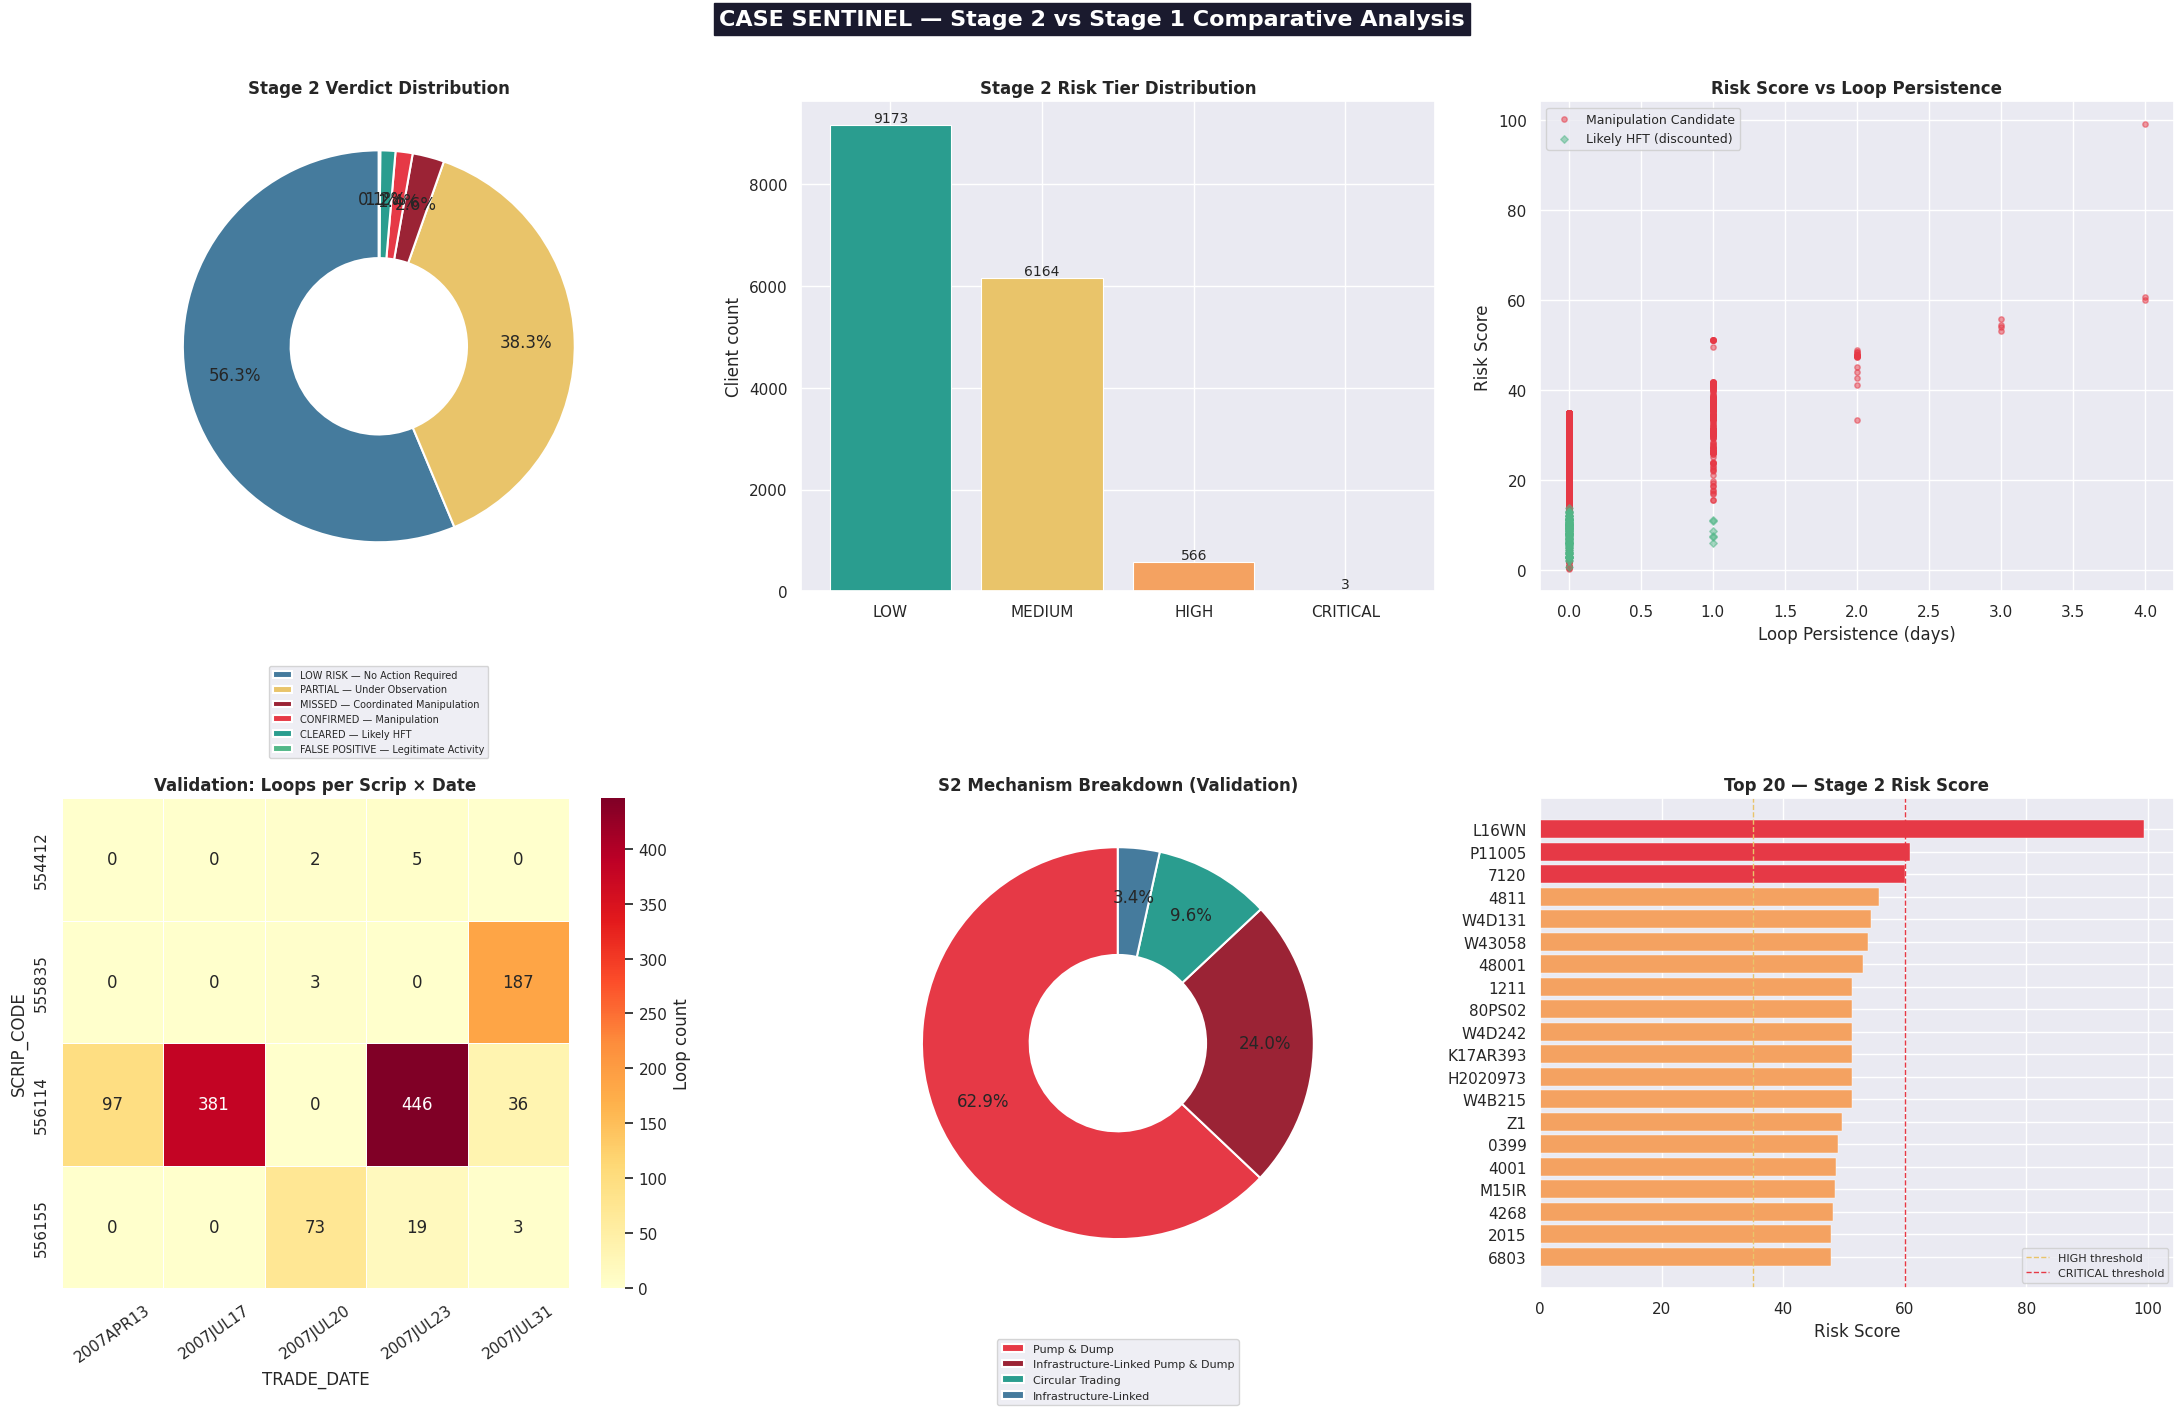

Figure S2-1 saved → E:\Synapse-BI\sentinel_charts\sentinel_s2_fig1_comparison.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE S2-1 — Stage 1 vs Stage 2 Comparison  (2 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(22, 14))
fig1.suptitle('CASE SENTINEL — Stage 2 vs Stage 1 Comparative Analysis',
              fontsize=16, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# ── 1a. DONUT — S2 Verdict distribution ──────────────────────────────────────
ax = axes[0, 0]
vdict_colors = {
    'CONFIRMED — Manipulation'             : '#E63946',
    'MISSED — Coordinated Manipulation'    : '#9B2335',
    'FALSE POSITIVE — Legitimate Activity' : '#52B788',
    'PARTIAL — Under Observation'          : '#E9C46A',
    'CLEARED — Likely HFT'                 : '#2A9D8F',
    'LOW RISK — No Action Required'        : '#457B9D',
}
wc = [vdict_colors.get(v, '#888') for v in verdict_summary.index]
ax.pie(verdict_summary.values, labels=None, colors=wc,
       autopct='%1.1f%%', startangle=90, pctdistance=0.75,
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
ax.legend(verdict_summary.index, loc='lower center', fontsize=7,
          bbox_to_anchor=(0.5, -0.35), ncol=1)
ax.set_title('Stage 2 Verdict Distribution', fontweight='bold')

# ── 1b. BAR — S2 Risk Tier Distribution ──────────────────────────────────────
ax = axes[0, 1]
tier_order = ['LOW','MEDIUM','HIGH','CRITICAL']
tier_counts = risk_df['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
bars = ax.bar(tier_counts.index,
              tier_counts.values,
              color=[TIER_CLR.get(t, '#888') for t in tier_counts.index],
              edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
ax.set_title('Stage 2 Risk Tier Distribution', fontweight='bold')
ax.set_ylabel('Client count')

# ── 1c. SCATTER — Stage 2 Risk Score vs Loop Persistence ─────────────────────
ax = axes[0, 2]
sc_data = risk_df[risk_df['Risk_Score'] > 0]
hft_mask = sc_data['hft_discount']
ax.scatter(sc_data.loc[~hft_mask,'persist_days'],
           sc_data.loc[~hft_mask,'Risk_Score'],
           c='#E63946', alpha=0.5, s=15, label='Manipulation Candidate')
ax.scatter(sc_data.loc[hft_mask,'persist_days'],
           sc_data.loc[hft_mask,'Risk_Score'],
           c='#52B788', alpha=0.5, s=15, marker='D', label='Likely HFT (discounted)')
ax.set_xlabel('Loop Persistence (days)')
ax.set_ylabel('Risk Score')
ax.set_title('Risk Score vs Loop Persistence', fontweight='bold')
ax.legend(fontsize=9)

# ── 1d. HEATMAP — Loop Matrix: Scrip × Date (validation only) ────────────────
ax = axes[1, 0]
if not s2_loops.empty:
    heat = (s2_loops.groupby(['SCRIP_CODE','TRADE_DATE'])
            .size().reset_index(name='n')
            .pivot(index='SCRIP_CODE', columns='TRADE_DATE', values='n').fillna(0))
    sns.heatmap(heat, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label':'Loop count'})
else:
    ax.text(0.5, 0.5, 'No loops detected', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
ax.set_title('Validation: Loops per Scrip × Date', fontweight='bold')
ax.tick_params(axis='x', rotation=35)

# ── 1e. DONUT — Mechanism breakdown (S2 only) ─────────────────────────────────
ax = axes[1, 1]
if not s2_loops.empty and 'mechanism' in s2_loops.columns:
    ms = s2_loops['mechanism'].value_counts()
    wc2 = [MECH_CLR.get(m, '#888') for m in ms.index]
    ax.pie(ms.values, labels=None, colors=wc2, autopct='%1.1f%%',
           startangle=90, pctdistance=0.75,
           wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
    ax.legend(ms.index, loc='lower center', fontsize=8,
              bbox_to_anchor=(0.5, -0.25), ncol=1)
else:
    ax.text(0.5, 0.5, 'No mechanism data', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
ax.set_title('S2 Mechanism Breakdown (Validation)', fontweight='bold')

# ── 1f. HORIZONTAL BAR — Top 20 entities by S2 Risk Score ────────────────────
ax = axes[1, 2]
top20 = risk_df_sorted.head(20).copy()
bar_colors = [
    '#52B788' if row['hft_discount'] else
    '#E63946' if row['Risk_Tier'] == 'CRITICAL' else
    '#F4A261' if row['Risk_Tier'] == 'HIGH' else '#E9C46A'
    for _, row in top20.iterrows()
]
ax.barh(top20['client'][::-1], top20['Risk_Score'][::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.3)
ax.set_title('Top 20 — Stage 2 Risk Score', fontweight='bold')
ax.set_xlabel('Risk Score')
ax.axvline(35, color='#E9C46A', linestyle='--', linewidth=1, label='HIGH threshold')
ax.axvline(60, color='#E63946', linestyle='--', linewidth=1, label='CRITICAL threshold')
ax.legend(fontsize=8)

plt.tight_layout()
fp = os.path.join(CHARTS_DIR, 'sentinel_s2_fig1_comparison.png')
plt.savefig(fp, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure S2-1 saved → {fp}')

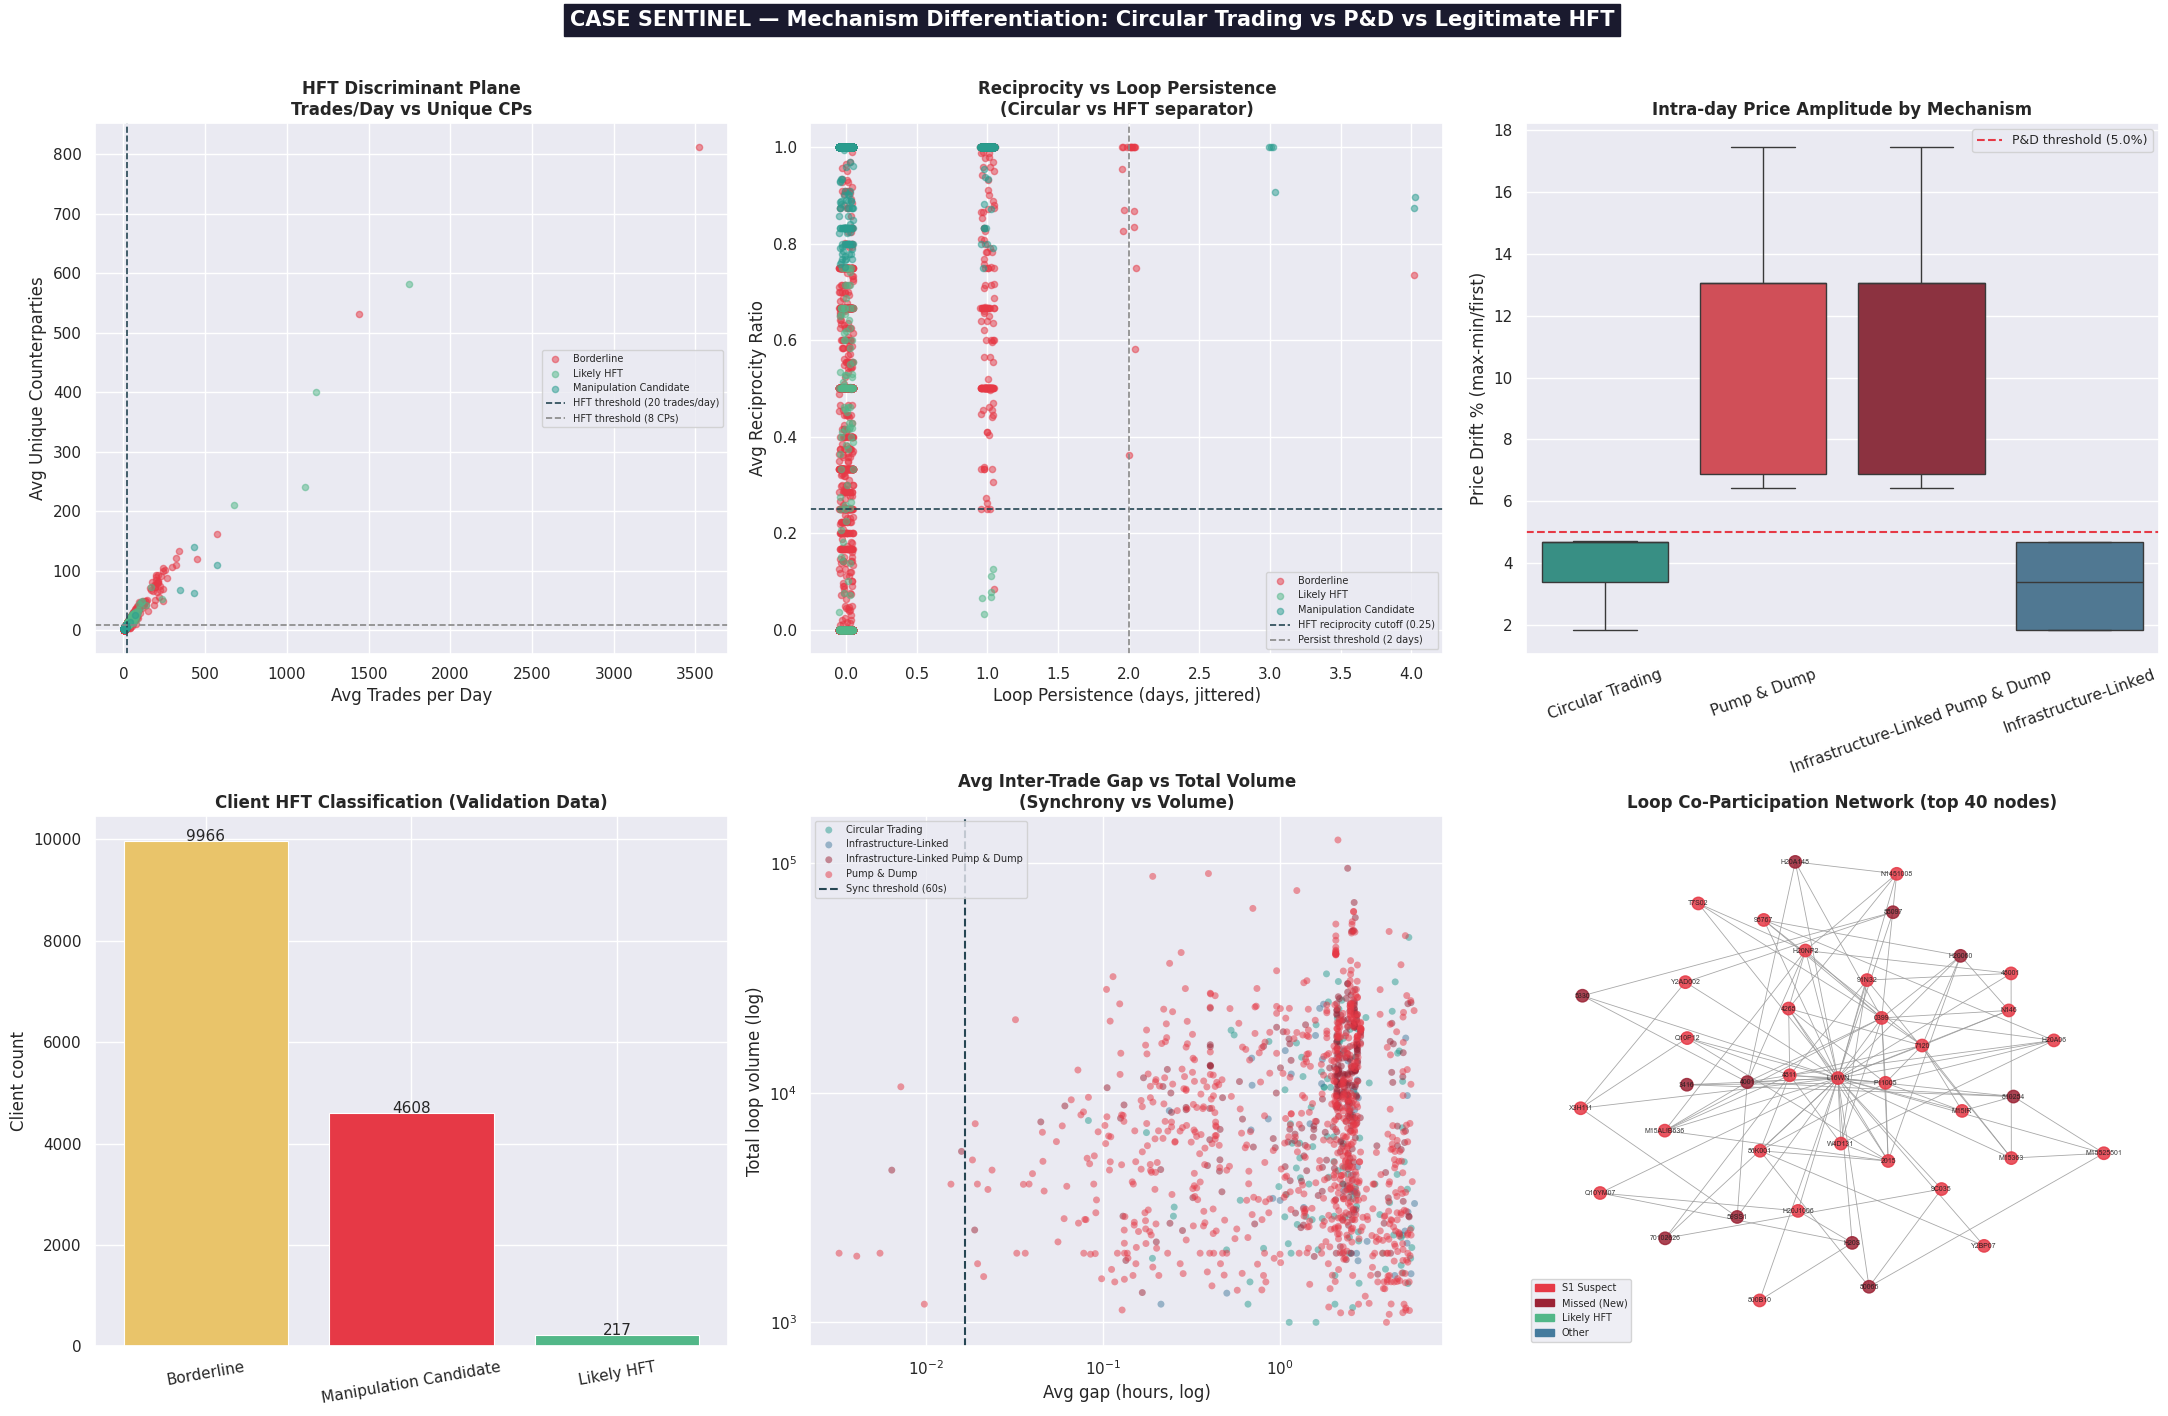

Figure S2-2 saved → E:\Synapse-BI\sentinel_charts\sentinel_s2_fig2_mechanism.png


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE S2-2 — Mechanism Differentiation Deep-Dive  (2 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 3, figsize=(22, 14))
fig2.suptitle(
    'CASE SENTINEL — Mechanism Differentiation: Circular Trading vs P&D vs Legitimate HFT',
    fontsize=15, fontweight='bold',
    color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01
)

# Client-level stats for charting
hft_stat_plot = client_val_stats.copy()
hft_stat_plot['color'] = hft_stat_plot['hft_classification'].map({
    'Likely HFT'            : '#52B788',
    'Manipulation Candidate': '#E63946',
    'Borderline'            : '#E9C46A',
})

# ── 2a. SCATTER — Trades/Day vs Unique CPs (HFT discriminant plane) ──────────
ax = axes2[0, 0]
for cls, grp in hft_stat_plot.groupby('hft_classification'):
    ax.scatter(grp['avg_trades_per_day'], grp['avg_unique_cps'],
               label=cls, alpha=0.5, s=20,
               color=MECH_CLR.get('Legitimate HFT' if 'HFT' in cls else
                                   'Circular Trading' if 'Manip' in cls else
                                   'Pump & Dump', '#E9C46A'))
# Decision boundary lines
ax.axvline(HFT_TRADES_PER_DAY,  color='#264653', linestyle='--', linewidth=1.2,
           label=f'HFT threshold ({HFT_TRADES_PER_DAY} trades/day)')
ax.axhline(HFT_MIN_COUNTERPARTS, color='#888',    linestyle='--', linewidth=1.2,
           label=f'HFT threshold ({HFT_MIN_COUNTERPARTS} CPs)')
ax.set_title('HFT Discriminant Plane\nTrades/Day vs Unique CPs', fontweight='bold')
ax.set_xlabel('Avg Trades per Day')
ax.set_ylabel('Avg Unique Counterparties')
ax.legend(fontsize=7)

# ── 2b. SCATTER — Reciprocity vs Loop Persistence ─────────────────────────────
ax = axes2[0, 1]
for cls, grp in hft_stat_plot.groupby('hft_classification'):
    grp2 = grp.merge(
        pd.DataFrame(list(client_loop_persist.items()),
                     columns=['client','loop_persist']),
        on='client', how='left'
    ).fillna({'loop_persist': 0})
    ax.scatter(grp2['loop_persist'] + np.random.uniform(-0.05, 0.05, len(grp2)),
               grp2['avg_reciprocity'],
               label=cls, alpha=0.5, s=20,
               color=MECH_CLR.get('Legitimate HFT' if 'HFT' in cls else
                                   'Circular Trading' if 'Manip' in cls else
                                   'Pump & Dump', '#E9C46A'))
ax.axhline(0.25, color='#264653', linestyle='--', linewidth=1.2,
           label='HFT reciprocity cutoff (0.25)')
ax.axvline(HFT_LOOP_PERSIST_DAYS, color='#888', linestyle='--', linewidth=1.2,
           label=f'Persist threshold ({HFT_LOOP_PERSIST_DAYS} days)')
ax.set_title('Reciprocity vs Loop Persistence\n(Circular vs HFT separator)', fontweight='bold')
ax.set_xlabel('Loop Persistence (days, jittered)')
ax.set_ylabel('Avg Reciprocity Ratio')
ax.legend(fontsize=7)

# ── 2c. BOX PLOT — Price Drift by Mechanism ──────────────────────────────────
ax = axes2[0, 2]
if not s2_loops.empty and 'mechanism' in s2_loops.columns and 'price_drift_pct' in s2_loops.columns:
    mechs_present = [m for m in MECH_CLR if m in s2_loops['mechanism'].values]
    sns.boxplot(data=s2_loops, x='mechanism', y='price_drift_pct',
                order=mechs_present,
                palette={m: MECH_CLR[m] for m in mechs_present},
                ax=ax, showfliers=True, linewidth=1.0)
    ax.axhline(PUMP_THRESHOLD, color='#E63946', linestyle='--', linewidth=1.5,
               label=f'P&D threshold ({PUMP_THRESHOLD}%)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=20)
else:
    ax.text(0.5, 0.5, 'No mechanism data', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
ax.set_title('Intra-day Price Amplitude by Mechanism', fontweight='bold')
ax.set_ylabel('Price Drift % (max-min/first)')
ax.set_xlabel('')

# ── 2d. HFT Classification counts ────────────────────────────────────────────
ax = axes2[1, 0]
hft_vc2 = hft_stat_plot['hft_classification'].value_counts()
bar_clrs = [
    '#52B788' if 'HFT' in k else
    '#E63946' if 'Manip' in k else '#E9C46A'
    for k in hft_vc2.index
]
ax.bar(hft_vc2.index, hft_vc2.values, color=bar_clrs, edgecolor='white', linewidth=0.8)
for i, v in enumerate(hft_vc2.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11)
ax.set_title('Client HFT Classification (Validation Data)', fontweight='bold')
ax.set_ylabel('Client count')
ax.tick_params(axis='x', rotation=10)

# ── 2e. SCATTER — Volume vs Avg Gap (sync indicator) per loop -─────────────── 
ax = axes2[1, 1]
if not s2_loops.empty and 'mechanism' in s2_loops.columns:
    for mech, grp in s2_loops.groupby('mechanism'):
        ax.scatter(
            grp['avg_gap_sec'].fillna(np.nan) / 3600,
            grp['total_volume'],
            label=mech, color=MECH_CLR.get(mech, '#888'),
            alpha=0.5, s=25, edgecolors='none'
        )
    ax.axvline(SYNC_GAP_SEC / 3600, color='#264653', linestyle='--', linewidth=1.5,
               label=f'Sync threshold ({SYNC_GAP_SEC}s)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, 'No loop data', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
ax.set_title('Avg Inter-Trade Gap vs Total Volume\n(Synchrony vs Volume)', fontweight='bold')
ax.set_xlabel('Avg gap (hours, log)')
ax.set_ylabel('Total loop volume (log)')

# ── 2f. Network graph — S2 loop clients (co-participation) ───────────────────
ax = axes2[1, 2]
if not s2_loops.empty and len(s2_loop_clients) > 0:
    G_co = nx.Graph()
    for _, row in s2_loops.iterrows():
        lc = [str(c).strip() for c in row['loop_clients']]
        mech = row.get('mechanism', 'Circular Trading')
        for a, b in combinations(lc, 2):
            if G_co.has_edge(a, b):
                G_co[a][b]['weight'] += 1
            else:
                G_co.add_edge(a, b, weight=1, mechanism=mech)

    # Limit to top-40 nodes by degree for clarity
    top_nodes = sorted(G_co.degree(), key=lambda x: x[1], reverse=True)[:40]
    top_node_set = {n for n, _ in top_nodes}
    G_sub = G_co.subgraph(top_node_set)

    pos = nx.spring_layout(G_sub, seed=42, k=1.5)
    node_colors = [
        '#52B788' if n in hft_client_set else
        '#9B2335' if n in missed_clients else
        '#E63946' if n in s1_known_suspects else '#457B9D'
        for n in G_sub.nodes()
    ]
    nx.draw_networkx(
        G_sub, pos=pos, ax=ax,
        node_color=node_colors,
        node_size=80, font_size=5,
        edge_color='#999', width=0.6, alpha=0.85, with_labels=True
    )
    # Legend
    patches = [
        mpatches.Patch(color='#E63946', label='S1 Suspect'),
        mpatches.Patch(color='#9B2335', label='Missed (New)'),
        mpatches.Patch(color='#52B788', label='Likely HFT'),
        mpatches.Patch(color='#457B9D', label='Other'),
    ]
    ax.legend(handles=patches, loc='lower left', fontsize=7)
else:
    ax.text(0.5, 0.5, 'No loop co-participation graph', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
ax.set_title('Loop Co-Participation Network (top 40 nodes)', fontweight='bold')
ax.axis('off')

plt.tight_layout()
fp2 = os.path.join(CHARTS_DIR, 'sentinel_s2_fig2_mechanism.png')
plt.savefig(fp2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure S2-2 saved → {fp2}')

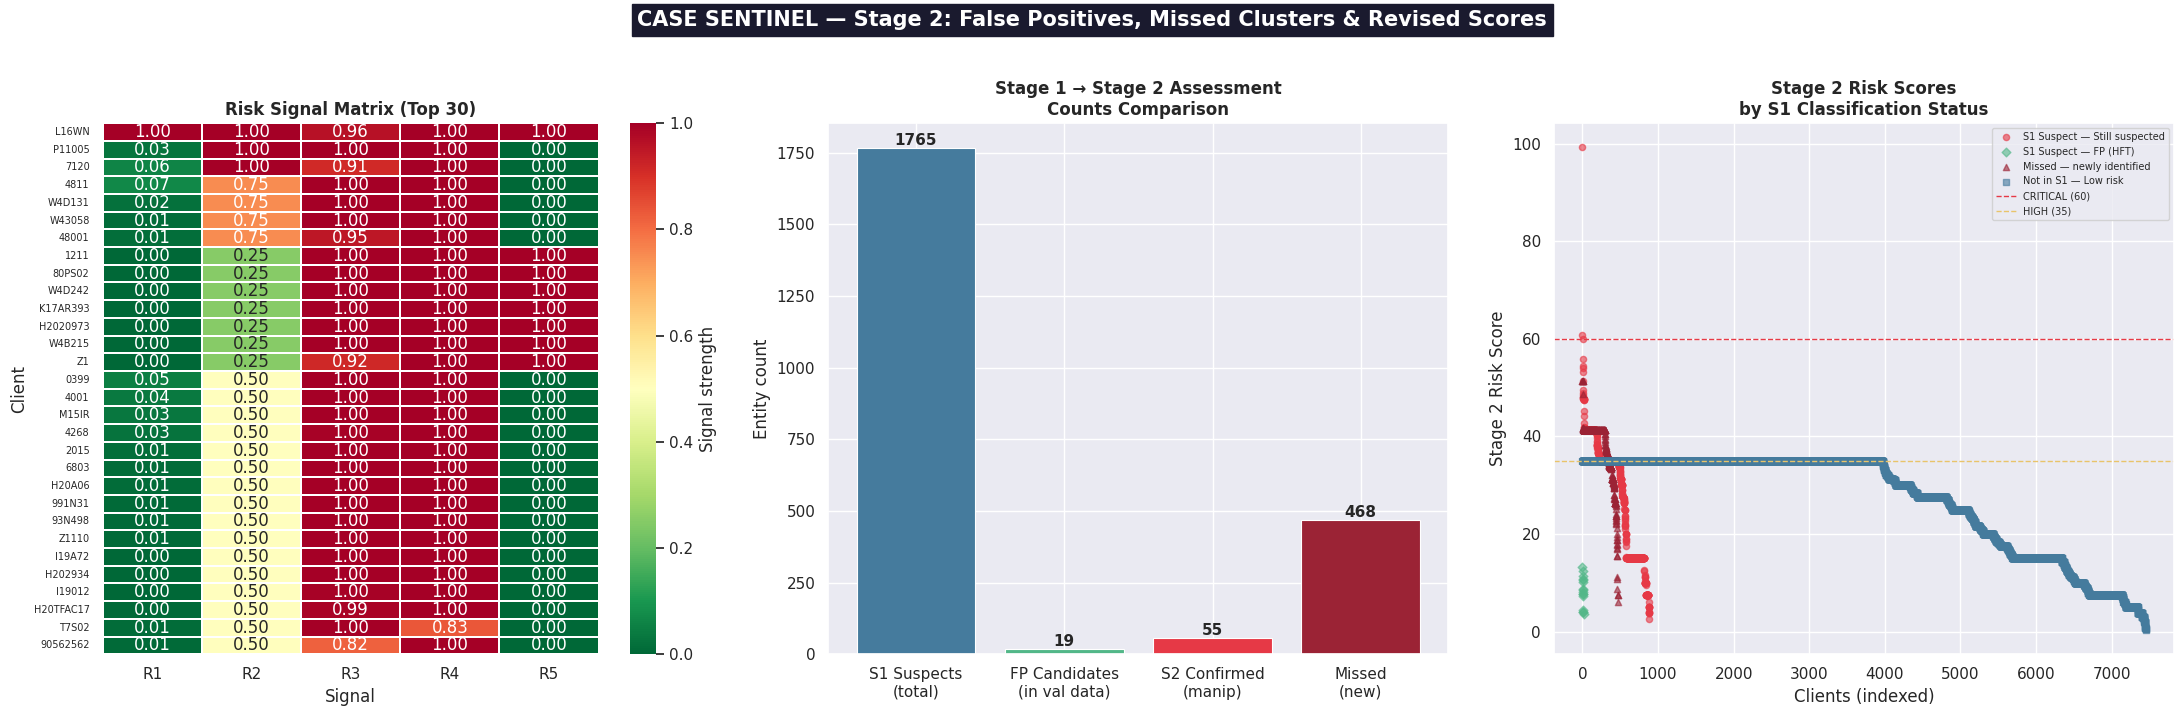

Figure S2-3 saved → E:\Synapse-BI\sentinel_charts\sentinel_s2_fig3_fp_missed.png


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE S2-3 — False Positives & Missed Clusters  (1 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(22, 7))
fig3.suptitle(
    'CASE SENTINEL — Stage 2: False Positives, Missed Clusters & Revised Scores',
    fontsize=15, fontweight='bold',
    color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.02
)

# ── 3a. SIGNAL HEATMAP — Top 30 clients × 5 risk signals ─────────────────────
ax = axes3[0]
top30 = risk_df_sorted.head(30)[['client'] + ['R1','R2','R3','R4','R5']].set_index('client')
sns.heatmap(top30, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
            annot=True, fmt='.2f', cbar_kws={'label':'Signal strength'},
            linewidths=0.3)
ax.set_title('Risk Signal Matrix (Top 30)', fontweight='bold')
ax.set_xlabel('Signal'); ax.set_ylabel('Client')
ax.tick_params(axis='y', labelsize=7)

# ── 3b. COMPARISON BAR — S1 vs S2 assessment counts ─────────────────────────
ax = axes3[1]
labels = ['S1 Suspects\n(total)', 'FP Candidates\n(in val data)', 
          'S2 Confirmed\n(manip)', 'Missed\n(new)']
values = [
    len(s1_known_suspects),
    len(false_positives),
    len(s2_confirmed),
    len(missed_clients)
]
bar_cols = ['#457B9D', '#52B788', '#E63946', '#9B2335']
bars = ax.bar(labels, values, color=bar_cols, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Stage 1 → Stage 2 Assessment\nCounts Comparison', fontweight='bold')
ax.set_ylabel('Entity count')

# ── 3c. SCATTER — S2 Risk Score vs S1 Suspect status ─────────────────────────
ax = axes3[2]
rd_plot = risk_df_sorted[risk_df_sorted['Risk_Score'] > 0].copy()
for status, clr, marker, lbl in [
    ((rd_plot['in_s1_suspects']) & (~rd_plot['is_fp']),     '#E63946', 'o', 'S1 Suspect — Still suspected'),
    (rd_plot['is_fp'],                                      '#52B788', 'D', 'S1 Suspect — FP (HFT)'),
    ((~rd_plot['in_s1_suspects']) & (rd_plot['is_missed']), '#9B2335', '^', 'Missed — newly identified'),
    ((~rd_plot['in_s1_suspects']) & (~rd_plot['is_missed']),
                                                            '#457B9D', 's', 'Not in S1 — Low risk'),
]:
    sub = rd_plot[status]
    if not sub.empty:
        ax.scatter(
            np.arange(len(sub)) + np.random.uniform(-0.5, 0.5, len(sub)),
            sub['Risk_Score'],
            c=clr, marker=marker, alpha=0.6, s=20, label=lbl
        )
ax.axhline(60, color='#E63946', linestyle='--', linewidth=1, label='CRITICAL (60)')
ax.axhline(35, color='#E9C46A', linestyle='--', linewidth=1, label='HIGH (35)')
ax.set_title('Stage 2 Risk Scores\nby S1 Classification Status', fontweight='bold')
ax.set_xlabel('Clients (indexed)')
ax.set_ylabel('Stage 2 Risk Score')
ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
fp3 = os.path.join(CHARTS_DIR, 'sentinel_s2_fig3_fp_missed.png')
plt.savefig(fp3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure S2-3 saved → {fp3}')

## Stage 2 Summary Report

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# STAGE 2 — FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────────────────
print()
print('╔' + '═'*62 + '╗')
print('║  CASE SENTINEL — STAGE 2 DEEP-DIVE REASSESSMENT           ║')
print('║  Enforcement Report  |  28 February 2026                  ║')
print('╠' + '═'*62 + '╣')
print('║  VALIDATION DATA SCOPE                                     ║')
print(f'║  Scrips   : {", ".join(sorted(VAL_SCRIPS)):<47}  ║')
print(f'║  Trades   : {len(val_trades):>7,} rows                                     ║')
print(f'║  Orders   : {len(val_orders):>7,} rows                                     ║')
print('╠' + '═'*62 + '╣')
print('║  LOOP DETECTION (VALIDATION SUBSET)                        ║')
s2l = len(s2_loops) if not s2_loops.empty else 0
print(f'║  Loops detected   : {s2l:>6,}                                  ║')
print(f'║  Loop participants: {len(s2_loop_clients):>6,}                                  ║')
print('╠' + '═'*62 + '╣')
print('║  FALSE POSITIVE ANALYSIS                                   ║')
print(f'║  FP Candidates (Likely HFT, no S2 loop): {len(false_positives):>5,}           ║')
print(f'║  S2-Confirmed Manipulators              : {len(s2_confirmed):>5,}           ║')
print('╠' + '═'*62 + '╣')
print('║  MISSED CLUSTER DETECTION                                  ║')
print(f'║  New entities not in S1 list: {len(missed_clients):>5,}                       ║')
print(f'║  Distinct new co-loop clusters: {len(missed_clusters):>3}                      ║')
print('╠' + '═'*62 + '╣')
print('║  MECHANISM BREAKDOWN (S2 LOOPS)                            ║')
if not s2_loops.empty and 'mechanism' in s2_loops.columns:
    for mech, cnt in s2_loops['mechanism'].value_counts().items():
        pct = cnt / len(s2_loops) * 100
        print(f'║  {mech:<38} {cnt:>5,}  ({pct:4.1f}%)  ║')
else:
    print('║  No loop mechanism data available                          ║')
print('╠' + '═'*62 + '╣')
print('║  REVISED RISK TIER DISTRIBUTION                            ║')
for tier in ['CRITICAL','HIGH','MEDIUM','LOW']:
    cnt = (risk_df_sorted['Risk_Tier'] == tier).sum()
    pct = cnt / len(risk_df_sorted) * 100
    print(f'║  {tier:<12} {cnt:>5,}  ({pct:4.1f}%)                              ║')
print('╚' + '═'*62 + '╝')


╔══════════════════════════════════════════════════════════════╗
║  CASE SENTINEL — STAGE 2 DEEP-DIVE REASSESSMENT           ║
║  Enforcement Report  |  28 February 2026                  ║
╠══════════════════════════════════════════════════════════════╣
║  VALIDATION DATA SCOPE                                     ║
║  Scrips   : 554412, 555835, 556114, 556155                   ║
║  Trades   : 115,140 rows                                     ║
║  Orders   : 504,364 rows                                     ║
╠══════════════════════════════════════════════════════════════╣
║  LOOP DETECTION (VALIDATION SUBSET)                        ║
║  Loops detected   :  1,252                                  ║
║  Loop participants:    730                                  ║
╠══════════════════════════════════════════════════════════════╣
║  FALSE POSITIVE ANALYSIS                                   ║
║  FP Candidates (Likely HFT, no S2 loop):    19           ║
║  S2-Confirmed Manipulators              

## S2.O — Order Book Deep-Dive Analysis

Five dedicated sections:
- **O1** — Order volume, type and member concentration
- **O2** — Wash-order cohort: full distribution and top actors
- **O3** — Order-to-trade conversion: layering / spoofing signals
- **O4** — Temporal clustering: synchronised order placement
- **O5** — Charts

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# S2.O1 — ORDER VOLUME, TYPE & MEMBER CONCENTRATION
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

# ── 1a. Overall order volume by scrip × date × side ──────────────────────────
scrip_date_side = (
    val_orders.groupby(['SCRIP_CODE', 'TRADE_DATE', 'order_side'])
    .agg(n_orders=('client_id', 'count'),
         n_clients=('client_id', 'nunique'),
         total_qty=('ORDER_QTY', 'sum'))
    .reset_index()
)

# ── 1b. Order type breakdown (market / limit / others) ───────────────────────
ord_type_dist = pd.Series(dtype=int)
if 'order_type' in val_orders.columns:
    ord_type_dist = (val_orders['order_type']
                     .astype(str).str.strip().str.upper()
                     .value_counts())

# ── 1c. Member-level order concentration ─────────────────────────────────────
member_ord = (
    val_orders.groupby('member_code')
    .agg(n_orders=('client_id', 'count'),
         n_clients=('client_id', 'nunique'),
         n_scrips=('SCRIP_CODE', 'nunique'))
    .reset_index()
    .sort_values('n_orders', ascending=False)
)
member_ord['pct_of_total'] = (member_ord['n_orders'] / len(val_orders) * 100).round(2)
member_ord['clients_per_order'] = (member_ord['n_clients'] / member_ord['n_orders']).round(4)

# ── 1d. Buy / Sell imbalance per scrip-date ───────────────────────────────────
pivot_side = (
    scrip_date_side.pivot_table(
        index=['SCRIP_CODE', 'TRADE_DATE'],
        columns='order_side', values='n_orders', fill_value=0)
    .reset_index()
)
for col in ['BUY', 'SELL']:
    if col not in pivot_side.columns:
        pivot_side[col] = 0
pivot_side['buy_sell_ratio'] = (pivot_side['BUY'] / pivot_side['SELL'].replace(0, np.nan)).round(3)
pivot_side['imbalance_pct']  = ((pivot_side['BUY'] - pivot_side['SELL']) /
                                 (pivot_side['BUY'] + pivot_side['SELL']) * 100).round(2)

# ── Print ─────────────────────────────────────────────────────────────────────
print('=' * 65)
print('  S2.O1 — ORDER VOLUME, TYPE & MEMBER CONCENTRATION')
print('=' * 65)
print(f'\n  Total orders : {len(val_orders):,}')
print(f'  Unique clients : {val_orders["client_id"].nunique():,}')
print(f'  Unique members : {val_orders["member_code"].nunique():,}')
print(f'  Scrips  : {val_orders["SCRIP_CODE"].nunique()}')
print(f'  Dates   : {val_orders["TRADE_DATE"].nunique()}')

print('\nBuy / Sell imbalance by scrip-date:')
print(pivot_side[['SCRIP_CODE', 'TRADE_DATE', 'BUY', 'SELL',
                   'buy_sell_ratio', 'imbalance_pct']].to_string(index=False))

if not ord_type_dist.empty:
    print('\nOrder type distribution:')
    for ot, cnt in ord_type_dist.items():
        print(f'  {ot:<20}  {cnt:>8,}  ({cnt/len(val_orders)*100:.1f}%)')

print(f'\nTop 15 members by order count (of {member_ord.shape[0]} total):')
print(member_ord.head(15).to_string(index=False))

  S2.O1 — ORDER VOLUME, TYPE & MEMBER CONCENTRATION

  Total orders : 504,364
  Unique clients : 31,031
  Unique members : 546
  Scrips  : 4
  Dates   : 7

Buy / Sell imbalance by scrip-date:
SCRIP_CODE TRADE_DATE     BUY    SELL  buy_sell_ratio  imbalance_pct
    554412  2007JUL20  1706.0  2732.0           0.624         -23.12
    554412  2007JUL23  1022.0  2172.0           0.471         -36.01
    554412  2007JUL31   524.0   820.0           0.639         -22.02
    555835  2007JUL23  1522.0  2260.0           0.673         -19.51
    555835  2007JUL31 13490.0 15624.0           0.863          -7.33
    556114  2007APR31  5996.0  9054.0           0.662         -20.32
    556114  2007JUL17 19382.0 33434.0           0.580         -26.61
    556114  2007JUL18 23942.0 32354.0           0.740         -14.94
    556114  2007JUL19 37582.0 40614.0           0.925          -3.88
    556114  2007JUL20 52722.0 56702.0           0.930          -3.64
    556114  2007JUL23 16658.0 21462.0           0

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# S2.O2 — WASH-ORDER COHORT: FULL DISTRIBUTION & TOP ACTORS
# ─────────────────────────────────────────────────────────────────────────────

# ── Tag each client FIRST so slices inherit it ────────────────────────────────
def _entity_tag(r):
    tags = []
    if r.get('in_s2_loop'):     tags.append('S2-Loop')
    if r.get('in_s1_suspects'): tags.append('S1-Known')
    if r.get('fp_candidate'):   tags.append('FP-Cleared')
    return ', '.join(tags) if tags else 'New Entity'

ord_client['entity_tag'] = ord_client.apply(_entity_tag, axis=1)

# ── Wash-rate bins & distribution ────────────────────────────────────────────
wash_bins   = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, np.inf]
wash_labels = ['0–10%','10–25%','25–50%','50–75%','75–100%','100–150%','>150%']
ord_client['wash_bin'] = pd.cut(ord_client['wash_rate'],
                                bins=wash_bins, labels=wash_labels, right=False)
wash_dist = ord_client['wash_bin'].value_counts().sort_index()

# ── Tier the wash suspects (after entity_tag exists) ─────────────────────────
WASH_HIGH = ord_client[ord_client['wash_rate'] >= 1.0].copy()
WASH_MED  = ord_client[(ord_client['wash_rate'] >= 0.5) &
                        (ord_client['wash_rate'] < 1.0)].copy()
WASH_LOW  = ord_client[(ord_client['wash_rate'] > 0) &
                        (ord_client['wash_rate'] < 0.5)].copy()

# Top wash actors by total orders
top_wash = WASH_HIGH.sort_values('total_orders', ascending=False).head(30)

# Wash volume by member
if 'member_code' in val_orders.columns:
    wash_clients_set = set(WASH_HIGH['client_id'])
    member_wash = (
        val_orders[val_orders['client_id'].isin(wash_clients_set)]
        .groupby('member_code')
        .agg(wash_orders=('client_id', 'count'),
             wash_clients=('client_id', 'nunique'))
        .reset_index()
        .sort_values('wash_clients', ascending=False)
    )
    member_wash['pct_of_total_orders'] = (
        member_wash['wash_orders'] / len(val_orders) * 100).round(2)
else:
    member_wash = pd.DataFrame()

print('=' * 65)
print('  S2.O2 — WASH-ORDER COHORT ANALYSIS')
print('=' * 65)
print(f'\n  Wash-rate distribution ({len(ord_client):,} total clients with order data):')
for lbl, cnt in wash_dist.items():
    bar = '█' * int(cnt / max(wash_dist) * 30)
    print(f'  {lbl:<10}  {cnt:>7,}  {bar}')

print(f'\n  HIGH wash tier  (≥100% rate): {len(WASH_HIGH):,} clients')
print(f'  MED  wash tier (50–100% rate): {len(WASH_MED):,} clients')
print(f'  LOW  wash tier   (0–50% rate): {len(WASH_LOW):,} clients')

print('\nEntity-tag breakdown (HIGH wash tier):')
print(WASH_HIGH['entity_tag'].value_counts().to_string())

print(f'\nTop 30 wash actors (HIGH tier, by total orders):')
print(top_wash[['client_id', 'total_orders', 'total_order_sessions',
                 'wash_order_sessions', 'wash_rate', 'entity_tag']].to_string(index=False))

if not member_wash.empty:
    print(f'\nTop 15 members facilitating HIGH-wash clients:')
    print(member_wash.head(15).to_string(index=False))

  S2.O2 — WASH-ORDER COHORT ANALYSIS

  Wash-rate distribution (31,031 total clients with order data):
  0–10%        16,647  ██████████████████████████████
  10–25%           36  
  25–50%          603  █
  50–75%        2,500  ████
  75–100%         253  
  100–150%     10,878  ███████████████████
  >150%           114  

  HIGH wash tier  (≥100% rate): 10,992 clients
  MED  wash tier (50–100% rate): 2,753 clients
  LOW  wash tier   (0–50% rate): 639 clients

Entity-tag breakdown (HIGH wash tier):
entity_tag
New Entity              9928
S1-Known                 507
S2-Loop                  344
S2-Loop, S1-Known        208
S1-Known, FP-Cleared       5

Top 30 wash actors (HIGH tier, by total orders):
client_id  total_orders  total_order_sessions  wash_order_sessions  wash_rate        entity_tag
    L16WN       96286.0                     7                   15   2.142857 S2-Loop, S1-Known
   W4D131        9290.0                     7                    9   1.285714 S2-Loop, S1-Known
 

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# S2.O3 — ORDER-TO-TRADE CONVERSION: LAYERING / SPOOFING SIGNALS
# High order count + low execution rate = possible spoofing / layering
# ─────────────────────────────────────────────────────────────────────────────

# ── Trade count per client (buy-side + sell-side) ────────────────────────────
buy_tc  = (val_trades.groupby('Buy Client Code')
           .size().rename_axis('client_id').rename('buy_trades'))
sell_tc = (val_trades.groupby('Sell Client Code')
           .size().rename_axis('client_id').rename('sell_trades'))
trade_counts = (pd.concat([buy_tc, sell_tc], axis=1)
                .fillna(0)
                .astype(int)
                .reset_index())
trade_counts['total_trades'] = trade_counts['buy_trades'] + trade_counts['sell_trades']

# ── Merge with order client profile ──────────────────────────────────────────
conv_df = ord_client.merge(
    trade_counts[['client_id', 'buy_trades', 'sell_trades', 'total_trades']],
    on='client_id', how='left'
).fillna({'buy_trades': 0, 'sell_trades': 0, 'total_trades': 0})

conv_df[['buy_trades','sell_trades','total_trades']] = (
    conv_df[['buy_trades','sell_trades','total_trades']].astype(int))

# ── Order-to-trade ratio (orders placed per executed trade) ──────────────────
conv_df['ord_per_trade'] = (
    conv_df['total_orders'] /
    conv_df['total_trades'].replace(0, np.nan)
)

# ── Spoofing proxy: ≥10 orders per trade AND wash rate > 0 ───────────────────
SPOOF_ORD_TRADE = 10
conv_df['spoof_signal'] = (
    (conv_df['ord_per_trade'] >= SPOOF_ORD_TRADE) &
    (conv_df['wash_rate'] > 0)
)
# Pure layering: many orders, zero trades
conv_df['pure_layering'] = (
    (conv_df['total_orders'] >= 10) &
    (conv_df['total_trades'] == 0)
)

spoof_cl    = conv_df[conv_df['spoof_signal']].sort_values('ord_per_trade', ascending=False)
layering_cl = conv_df[conv_df['pure_layering']].sort_values('total_orders', ascending=False)

# ── Cross-tag with loop / risk status ─────────────────────────────────────────
spoof_cl['entity_tag'] = spoof_cl['client_id'].map(
    lambda c: (
        'S2-Loop'   if c in s2_loop_clients   else
        'S1-Known'  if c in s1_known_suspects  else
        'New Entity'
    )
)
layering_cl['entity_tag'] = layering_cl['client_id'].map(
    lambda c: (
        'S2-Loop'   if c in s2_loop_clients   else
        'S1-Known'  if c in s1_known_suspects  else
        'New Entity'
    )
)

print('=' * 65)
print('  S2.O3 — ORDER-TO-TRADE CONVERSION (LAYERING / SPOOFING)')
print('=' * 65)
print(f'\n  Clients with order + trade data : {conv_df[conv_df["total_trades"]>0].shape[0]:,}')
print(f'  Clients with orders but 0 trades : {conv_df[conv_df["total_trades"]==0].shape[0]:,}')
print()
print(f'  Spoofing signal (≥{SPOOF_ORD_TRADE} orders/trade + wash>0):')
print(f'    Total            : {len(spoof_cl):,}')
print(f'    In S2 loop       : {spoof_cl["entity_tag"].eq("S2-Loop").sum():,}')
print(f'    S1 Known         : {spoof_cl["entity_tag"].eq("S1-Known").sum():,}')
print(f'    New Entity       : {spoof_cl["entity_tag"].eq("New Entity").sum():,}')
print()
print(f'  Pure layering (≥10 orders, 0 trades):')
print(f'    Total            : {len(layering_cl):,}')
print(f'    In S2 loop       : {layering_cl["entity_tag"].eq("S2-Loop").sum():,}')
print(f'    New Entity       : {layering_cl["entity_tag"].eq("New Entity").sum():,}')

print(f'\nTop 20 spoofing-signal clients (highest order-to-trade ratio):')
show_cols = ['client_id','total_orders','total_trades','ord_per_trade',
             'wash_rate','entity_tag']
print(spoof_cl[show_cols].head(20).to_string(index=False))

print(f'\nTop 20 pure-layering clients (orders placed, zero trades executed):')
print(layering_cl[['client_id','total_orders','total_order_sessions',
                    'wash_rate','entity_tag']].head(20).to_string(index=False))

  S2.O3 — ORDER-TO-TRADE CONVERSION (LAYERING / SPOOFING)

  Clients with order + trade data : 14,547
  Clients with orders but 0 trades : 16,484

  Spoofing signal (≥10 orders/trade + wash>0):
    Total            : 211
    In S2 loop       : 4
    S1 Known         : 14
    New Entity       : 193

  Pure layering (≥10 orders, 0 trades):
    Total            : 3,429
    In S2 loop       : 0
    New Entity       : 3,200

Top 20 spoofing-signal clients (highest order-to-trade ratio):
 client_id  total_orders  total_trades  ord_per_trade  wash_rate entity_tag
     73531         728.0             4     182.000000   0.750000   S1-Known
      F228         132.0             2      66.000000   1.000000 New Entity
K17F00A207         102.0             2      51.000000   1.000000 New Entity
    K17346          92.0             2      46.000000   0.666667 New Entity
      0VNP          84.0             2      42.000000   1.000000 New Entity
    35M173          80.0             2      40.000000   1

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# S2.O4 — TEMPORAL ORDER CLUSTERING & SYNCHRONISED PLACEMENT
# Fully vectorised: deduped self-join on 60-second slot buckets
# Restricted to HIGH-wash clients (≥100% rate) to keep dataset tractable
# ─────────────────────────────────────────────────────────────────────────────

SYNC_WINDOW = 60  # seconds

# ── Parse order time ──────────────────────────────────────────────────────────
vo = val_orders.copy()
vo['ORDER_TIME_DT'] = pd.to_datetime(vo['ORDER_TIME'], errors='coerce', format='mixed')
vo['order_hour']    = vo['ORDER_TIME_DT'].dt.hour
vo['order_minute']  = vo['ORDER_TIME_DT'].dt.minute

# ── Flag wash-tier (≥50%) for hourly / peak analysis ─────────────────────────
wash_all_set         = set(ord_client[ord_client['wash_rate'] >= 0.5]['client_id'])
vo['is_wash_client'] = vo['client_id'].isin(wash_all_set)

# ── Hourly volume distribution ────────────────────────────────────────────────
hourly_all  = vo.groupby('order_hour').size().rename('all_orders')
hourly_wash = vo[vo['is_wash_client']].groupby('order_hour').size().rename('wash_orders')
hourly = pd.concat([hourly_all, hourly_wash], axis=1).fillna(0).astype(int)
hourly['wash_share_pct'] = (hourly['wash_orders'] / hourly['all_orders'] * 100).round(1)

# ── Peak 15-minute windows ────────────────────────────────────────────────────
vo['slot_15m'] = (vo['order_hour'] * 60 + vo['order_minute']) // 15 * 15
peak_slots = (
    vo.groupby(['SCRIP_CODE', 'TRADE_DATE', 'slot_15m'])
    .agg(n_orders      =('client_id', 'count'),
         n_wash_clients=('is_wash_client', 'sum'),
         n_clients     =('client_id', 'nunique'))
    .reset_index()
    .sort_values('n_orders', ascending=False)
)
peak_slots['slot_time'] = peak_slots['slot_15m'].apply(
    lambda x: f"{x//60:02d}:{x%60:02d}")

# ── Sync-pair detection: vectorised self-join (HIGH-wash clients only) ────────
# Restrict to clients with wash_rate ≥ 1.0 to keep the self-join small
_high_wash_set = set(WASH_HIGH['client_id'])
vo_hw = vo[
    vo['is_wash_client'] &
    vo['client_id'].isin(_high_wash_set) &
    vo['ORDER_TIME_DT'].notna()
].copy()

sync_pair_df = pd.DataFrame(columns=['client_a', 'client_b', 'sync_events'])
if not vo_hw.empty:
    vo_hw['ts_sec'] = (vo_hw['ORDER_TIME_DT'].astype('int64') // 1_000_000_000)
    vo_hw['bucket'] = vo_hw['ts_sec'] // SYNC_WINDOW

    # One row per (scrip, date, bucket, client) — avoids duplicate counting
    vo_dedup = (vo_hw[['SCRIP_CODE', 'TRADE_DATE', 'bucket', 'client_id']]
                .drop_duplicates())

    # Vectorised self-join on identical bucket
    m = vo_dedup.merge(vo_dedup,
                       on=['SCRIP_CODE', 'TRADE_DATE', 'bucket'],
                       suffixes=('_a', '_b'))
    m = m[m['client_id_a'] < m['client_id_b']]   # dedupe pair direction

    if not m.empty:
        sync_pair_df = (m.groupby(['client_id_a', 'client_id_b'])
                        .size()
                        .reset_index(name='sync_events')
                        .rename(columns={'client_id_a': 'client_a',
                                         'client_id_b': 'client_b'})
                        .sort_values('sync_events', ascending=False))

high_sync = sync_pair_df[sync_pair_df['sync_events'] >= 3] if not sync_pair_df.empty else sync_pair_df

# ── Print ─────────────────────────────────────────────────────────────────────
print('=' * 65)
print('  S2.O4 — TEMPORAL ORDER CLUSTERING & SYNC ANALYSIS')
print('=' * 65)
print(f'\n  Orders with parsable timestamp : {vo["ORDER_TIME_DT"].notna().sum():,}')
print(f'  HIGH-wash clients analysed for sync : {len(_high_wash_set):,}')

print('\nHourly order volume (all vs wash-tier):')
print(f'  {"Hour":>4}  {"All Orders":>11}  {"Wash Orders":>12}  {"Wash%":>6}')
for hr, row in hourly.iterrows():
    bar = '▓' * int(row['wash_share_pct'] / 5)
    print(f'  {hr:>4}  {int(row["all_orders"]):>11,}  '
          f'{int(row["wash_orders"]):>12,}  {row["wash_share_pct"]:>5.1f}%  {bar}')

print(f'\nTop 15 peak 15-minute windows:')
print(peak_slots[['SCRIP_CODE', 'TRADE_DATE', 'slot_time', 'n_orders',
                   'n_wash_clients', 'n_clients']].head(15).to_string(index=False))

print(f'\nSynchronised order pairs (HIGH-wash clients, 60-sec bucket):')
print(f'  Total unique pairs          : {len(sync_pair_df):,}')
print(f'  High-sync pairs (≥3 events) : {len(high_sync):,}')
if not high_sync.empty:
    print(f'\nTop 20 most synchronised pairs:')
    print(high_sync.head(20).to_string(index=False))

  S2.O4 — TEMPORAL ORDER CLUSTERING & SYNC ANALYSIS

  Orders with parsable timestamp : 504,364
  HIGH-wash clients analysed for sync : 10,992

Hourly order volume (all vs wash-tier):
  Hour   All Orders   Wash Orders   Wash%
     8            8             6   75.0%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
     9       38,674        31,278   80.9%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    10      172,342       139,928   81.2%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    11       86,498        73,180   84.6%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    12       49,026        41,278   84.2%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    13       53,894        46,878   87.0%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    14       51,446        45,466   88.4%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    15       52,154        46,430   89.0%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    16          248           174   70.2%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    17           70            52   74.3%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    18            4             0    0.0%  

Top 15 peak 15-minute windows:
SCRIP_CODE TRADE_DATE slot_time  n_orders  n_wash_clients  n_clients
    556114  2007JUL19     13:00

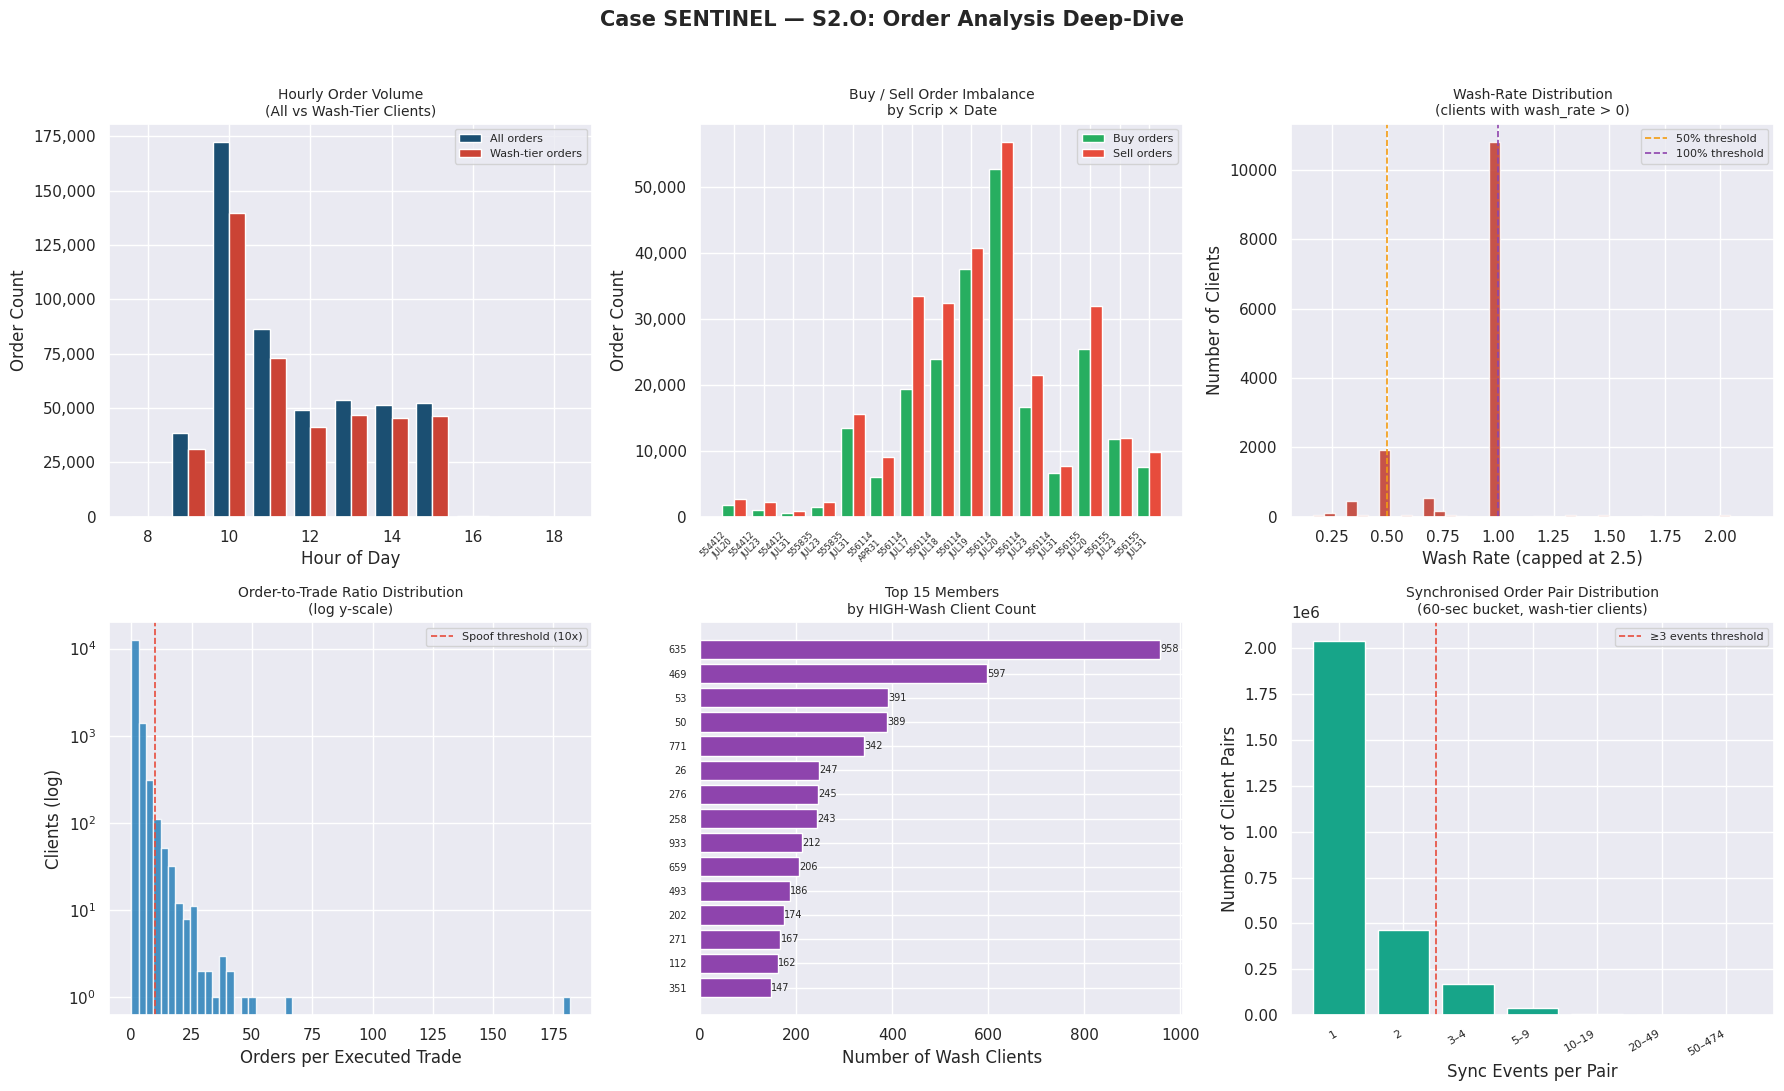

✓ Order analysis chart saved → E:\Synapse-BI\sentinel_charts\sentinel_s2_fig4_orders.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# S2.O5 — ORDER DEEP-DIVE: 2×3 CHART PANEL
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

fig_o, axes_o = plt.subplots(2, 3, figsize=(18, 11))
fig_o.suptitle('Case SENTINEL — S2.O: Order Analysis Deep-Dive',
               fontsize=15, fontweight='bold', y=0.99)

# ── O5-A: Hourly order volume — all vs wash-tier ──────────────────────────────
ax = axes_o[0, 0]
hrs = hourly.index
w   = 0.4
ax.bar(hrs - w/2, hourly['all_orders'],  width=w, color='#1B4F72', label='All orders')
ax.bar(hrs + w/2, hourly['wash_orders'], width=w, color='#CB4335', label='Wash-tier orders')
ax.set_title('Hourly Order Volume\n(All vs Wash-Tier Clients)', fontsize=10)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Order Count')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── O5-B: Buy / Sell imbalance per scrip-date ────────────────────────────────
ax = axes_o[0, 1]
if not pivot_side.empty and 'BUY' in pivot_side.columns and 'SELL' in pivot_side.columns:
    labels_bs = [f"{r.SCRIP_CODE}\n{r.TRADE_DATE[-5:]}"
                 for _, r in pivot_side.iterrows()]
    x_bs = np.arange(len(labels_bs))
    ax.bar(x_bs - 0.2, pivot_side['BUY'],  width=0.4, color='#27AE60', label='Buy orders')
    ax.bar(x_bs + 0.2, pivot_side['SELL'], width=0.4, color='#E74C3C', label='Sell orders')
    ax.set_xticks(x_bs)
    ax.set_xticklabels(labels_bs, fontsize=6, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)
ax.set_title('Buy / Sell Order Imbalance\nby Scrip × Date', fontsize=10)
ax.set_ylabel('Order Count')

# ── O5-C: Wash rate distribution ─────────────────────────────────────────────
ax = axes_o[0, 2]
wr_vals = ord_client['wash_rate'].dropna()
wr_vals = wr_vals[wr_vals > 0]
if not wr_vals.empty:
    ax.hist(wr_vals.clip(upper=2.5), bins=40, color='#C0392B', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='#F39C12', linestyle='--', linewidth=1.2, label='50% threshold')
ax.axvline(1.0, color='#8E44AD', linestyle='--', linewidth=1.2, label='100% threshold')
ax.set_title('Wash-Rate Distribution\n(clients with wash_rate > 0)', fontsize=10)
ax.set_xlabel('Wash Rate (capped at 2.5)'); ax.set_ylabel('Number of Clients')
ax.legend(fontsize=8)

# ── O5-D: Order-to-trade ratio distribution ──────────────────────────────────
ax = axes_o[1, 0]
otr = conv_df['ord_per_trade'].dropna()
otr = otr[(otr > 0) & (otr < 1000)]
if not otr.empty:
    ax.hist(otr, bins=60, color='#2980B9', edgecolor='white', alpha=0.85, log=True)
ax.axvline(SPOOF_ORD_TRADE, color='#E74C3C', linestyle='--',
           linewidth=1.2, label=f'Spoof threshold ({SPOOF_ORD_TRADE}x)')
ax.set_title('Order-to-Trade Ratio Distribution\n(log y-scale)', fontsize=10)
ax.set_xlabel('Orders per Executed Trade'); ax.set_ylabel('Clients (log)')
ax.legend(fontsize=8)

# ── O5-E: Top 15 members by wash-client count ────────────────────────────────
ax = axes_o[1, 1]
if 'member_wash' in dir() and not member_wash.empty:
    top_mw = member_wash.head(15).reset_index(drop=True)
    bars_e = ax.barh(range(len(top_mw)), top_mw['wash_clients'],
                     color='#8E44AD', edgecolor='white')
    ax.set_yticks(range(len(top_mw)))
    ax.set_yticklabels(top_mw['member_code'].astype(str), fontsize=7)
    ax.invert_yaxis()
    for b, (_, r) in zip(bars_e, top_mw.iterrows()):
        ax.text(b.get_width() + 0.2, b.get_y() + b.get_height() / 2,
                str(int(r['wash_clients'])), va='center', fontsize=7)
else:
    ax.text(0.5, 0.5, 'No member data', ha='center', va='center',
            transform=ax.transAxes, fontsize=10)
ax.set_title('Top 15 Members\nby HIGH-Wash Client Count', fontsize=10)
ax.set_xlabel('Number of Wash Clients')

# ── O5-F: Sync pair distribution ─────────────────────────────────────────────
ax = axes_o[1, 2]
_spdf = globals().get('sync_pair_df', pd.DataFrame())
if not _spdf.empty:
    _max = int(_spdf['sync_events'].max()) + 1
    sc_bins = sorted(set([1, 2, 3, 5, 10, 20, 50, _max]))
    sc_lbls = [f"{sc_bins[i]}–{sc_bins[i+1]-1}" if sc_bins[i+1]-1 > sc_bins[i]
               else str(sc_bins[i]) for i in range(len(sc_bins)-1)]
    sc_cut  = pd.cut(_spdf['sync_events'], bins=sc_bins,
                     labels=sc_lbls[:len(sc_bins)-1], right=False)
    sc_dist = sc_cut.value_counts().sort_index()
    bars_f  = ax.bar(range(len(sc_dist)), sc_dist.values,
                     color='#17A589', edgecolor='white')
    ax.set_xticks(range(len(sc_dist)))
    ax.set_xticklabels(sc_dist.index.tolist(), fontsize=8, rotation=30, ha='right')
    # Mark the ≥3 threshold
    thresh_lbl = next((l for l in sc_dist.index if l.startswith('3')), None)
    if thresh_lbl and thresh_lbl in sc_dist.index.tolist():
        ax.axvline(sc_dist.index.tolist().index(thresh_lbl) - 0.5,
                   color='#E74C3C', linestyle='--', linewidth=1.2,
                   label='≥3 events threshold')
        ax.legend(fontsize=8)
    ax.set_ylabel('Number of Client Pairs')
else:
    ax.text(0.5, 0.5, 'Run S2.O4 first', ha='center', va='center',
            transform=ax.transAxes, fontsize=10)
ax.set_title('Synchronised Order Pair Distribution\n(60-sec bucket, wash-tier clients)', fontsize=10)
ax.set_xlabel('Sync Events per Pair')

plt.tight_layout(rect=[0, 0, 1, 0.97])
_fp_ord = os.path.join(globals().get('CHARTS_DIR', r'E:\Synapse-BI\sentinel_charts'),
                       'sentinel_s2_fig4_orders.png')
fig_o.savefig(_fp_ord, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Order analysis chart saved → {_fp_ord}')

## S2.9 — Export: Enforcement Presentation (PDF)

In [20]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "reportlab"])
print("reportlab ready")

reportlab ready


In [1]:
!pip install reportlab


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import os, textwrap
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER, TA_RIGHT
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    HRFlowable, PageBreak, Image, KeepTogether
)
from reportlab.platypus.flowables import HRFlowable

# ── output path (works whether cells 1-2 ran or not) ─────────────────────────
_CHARTS_DIR = globals().get("CHARTS_DIR", r"E:\Synapse-BI\sentinel_charts")
os.makedirs(_CHARTS_DIR, exist_ok=True)
PDF_OUT = os.path.join(_CHARTS_DIR, "sentinel_stage2_enforcement_report.pdf")

# ── colour palette ────────────────────────────────────────────────────────────
C_NAVY   = colors.HexColor("#0D1B2A")
C_BLUE   = colors.HexColor("#1B4F72")
C_TEAL   = colors.HexColor("#148F77")
C_AMBER  = colors.HexColor("#D4AC0D")
C_RED    = colors.HexColor("#CB4335")
C_LGREY  = colors.HexColor("#F2F3F4")
C_MGREY  = colors.HexColor("#D5D8DC")
C_WHITE  = colors.white
C_BLACK  = colors.black

# ── styles ────────────────────────────────────────────────────────────────────
styles = getSampleStyleSheet()

def S(name, **kw):
    return ParagraphStyle(name, **kw)

sTitle     = S("sTitle",    fontName="Helvetica-Bold",  fontSize=22, textColor=C_WHITE,
                             alignment=TA_CENTER, spaceAfter=4)
sSubtitle  = S("sSubtitle", fontName="Helvetica",       fontSize=11, textColor=C_MGREY,
                             alignment=TA_CENTER, spaceAfter=6)
sSection   = S("sSection",  fontName="Helvetica-Bold",  fontSize=13, textColor=C_NAVY,
                             spaceBefore=10, spaceAfter=4)
sBody      = S("sBody",     fontName="Helvetica",       fontSize=9,  textColor=C_BLACK,
                             spaceAfter=3, leading=13)
sCaption   = S("sCaption",  fontName="Helvetica-Oblique",fontSize=8, textColor=C_BLUE,
                             alignment=TA_CENTER, spaceAfter=6)
sBullet    = S("sBullet",   fontName="Helvetica",       fontSize=9,  textColor=C_BLACK,
                             leftIndent=14, spaceAfter=2, leading=13)
sNote      = S("sNote",     fontName="Helvetica-Oblique",fontSize=8, textColor=C_BLUE,
                             leftIndent=6, spaceAfter=4, leading=11)
sTH        = S("sTH",       fontName="Helvetica-Bold",  fontSize=8,  textColor=C_WHITE,
                             alignment=TA_CENTER)
sTD        = S("sTD",       fontName="Helvetica",       fontSize=8,  textColor=C_BLACK,
                             alignment=TA_LEFT, leading=11)
sTDC       = S("sTDC",      fontName="Helvetica",       fontSize=8,  textColor=C_BLACK,
                             alignment=TA_CENTER, leading=11)
sSlideHdr  = S("sSlideHdr", fontName="Helvetica-Bold",  fontSize=16, textColor=C_WHITE,
                             alignment=TA_LEFT, spaceAfter=2)
sSlideNum  = S("sSlideNum", fontName="Helvetica",       fontSize=9,  textColor=C_MGREY,
                             alignment=TA_RIGHT)

# ── helper: slide header banner ───────────────────────────────────────────────
def slide_header(slide_num, total, headline, subtitle=""):
    hdr = Table([[
        Paragraph("CASE SENTINEL  ·  Stage 2 Enforcement Report  ·  28 Feb 2026", sSlideNum),
        Paragraph(f"Slide {slide_num} / {total}", sSlideNum),
    ]], colWidths=[13*cm, 4.5*cm])
    hdr.setStyle(TableStyle([
        ("BACKGROUND",   (0,0),(-1,-1), C_NAVY),
        ("TOPPADDING",   (0,0),(-1,-1), 4),
        ("BOTTOMPADDING",(0,0),(-1,-1), 4),
        ("LEFTPADDING",  (0,0),(-1,-1), 6),
    ]))
    hl = Table([[Paragraph(headline, sSlideHdr)]], colWidths=[17.5*cm])
    hl.setStyle(TableStyle([
        ("BACKGROUND",   (0,0),(-1,-1), C_BLUE),
        ("TOPPADDING",   (0,0),(-1,-1), 8),
        ("BOTTOMPADDING",(0,0),(-1,-1), 8),
        ("LEFTPADDING",  (0,0),(-1,-1), 10),
    ]))
    elems = [hdr, hl]
    if subtitle:
        elems.append(Paragraph(subtitle, sSubtitle))
    elems.append(Spacer(1, 0.25*cm))
    return elems

# ── helper: section heading ───────────────────────────────────────────────────
def sec(txt):
    t = Table([[Paragraph(txt, sSection)]], colWidths=[17.5*cm])
    t.setStyle(TableStyle([
        ("BACKGROUND",   (0,0),(-1,-1), C_LGREY),
        ("LEFTPADDING",  (0,0),(-1,-1), 8),
        ("TOPPADDING",   (0,0),(-1,-1), 4),
        ("BOTTOMPADDING",(0,0),(-1,-1), 4),
        ("LINEBELOW",    (0,0),(-1,-1), 1.5, C_BLUE),
    ]))
    return t

# ── helper: generic data table ────────────────────────────────────────────────
def make_table(headers, rows, col_widths):
    hrow = [Paragraph(h, sTH) for h in headers]
    body = [[Paragraph(str(c), sTDC if i > 0 else sTD) for i,c in enumerate(r)] for r in rows]
    t = Table([hrow] + body, colWidths=col_widths, repeatRows=1)
    t.setStyle(TableStyle([
        ("BACKGROUND",    (0,0),  (-1,0),  C_BLUE),
        ("ROWBACKGROUNDS",(0,1),  (-1,-1), [C_WHITE, C_LGREY]),
        ("GRID",          (0,0),  (-1,-1), 0.3, C_MGREY),
        ("TOPPADDING",    (0,0),  (-1,-1), 3),
        ("BOTTOMPADDING", (0,0),  (-1,-1), 3),
        ("LEFTPADDING",   (0,0),  (-1,-1), 5),
        ("RIGHTPADDING",  (0,0),  (-1,-1), 5),
    ]))
    return t

# ── helper: metric grid ───────────────────────────────────────────────────────
def metric_box(pairs, cols=3):
    bgs = [C_NAVY, C_BLUE, C_TEAL, C_NAVY, C_BLUE, C_TEAL]
    def cell(label, value, bg):
        inner = Table([
            [Paragraph(value, S(f"mv{label}", fontName="Helvetica-Bold", fontSize=16,
                                textColor=C_WHITE, alignment=TA_CENTER))],
            [Paragraph(label, S(f"ml{label}", fontName="Helvetica", fontSize=7,
                                textColor=C_MGREY, alignment=TA_CENTER))],
        ], colWidths=[5.5*cm])
        inner.setStyle(TableStyle([
            ("BACKGROUND",    (0,0),(-1,-1), bg),
            ("TOPPADDING",    (0,0),(-1,-1), 6),
            ("BOTTOMPADDING", (0,0),(-1,-1), 6),
        ]))
        return inner
    row_cells, all_rows = [], []
    for i,(lbl,val) in enumerate(pairs):
        row_cells.append(cell(lbl, val, bgs[i % len(bgs)]))
        if len(row_cells) == cols:
            all_rows.append(row_cells); row_cells = []
    if row_cells:
        while len(row_cells) < cols: row_cells.append(Spacer(1,1))
        all_rows.append(row_cells)
    t = Table(all_rows, colWidths=[5.6*cm]*cols)
    t.setStyle(TableStyle([
        ("ALIGN",         (0,0),(-1,-1), "CENTER"),
        ("VALIGN",        (0,0),(-1,-1), "MIDDLE"),
        ("LEFTPADDING",   (0,0),(-1,-1), 3),
        ("RIGHTPADDING",  (0,0),(-1,-1), 3),
        ("TOPPADDING",    (0,0),(-1,-1), 3),
        ("BOTTOMPADDING", (0,0),(-1,-1), 3),
    ]))
    return t

# ── helper: embed chart ───────────────────────────────────────────────────────
def chart_img(fname, caption, width=17*cm):
    path = os.path.join(_CHARTS_DIR, fname)
    elems = []
    if os.path.exists(path):
        elems.append(Image(path, width=width, height=width*0.52))
    else:
        elems.append(Paragraph(f"[Chart not found: {fname}]", sNote))
    elems.append(Paragraph(caption, sCaption))
    return elems

# ═════════════════════════════════════════════════════════════════════════════
# BUILD DOCUMENT
# ═════════════════════════════════════════════════════════════════════════════
doc = SimpleDocTemplate(
    PDF_OUT, pagesize=A4,
    leftMargin=1.8*cm, rightMargin=1.8*cm,
    topMargin=1.5*cm,  bottomMargin=1.8*cm,
    title="Case SENTINEL — Stage 2 Enforcement Report",
    author="Synapse-BI Surveillance Analytics",
)
story = []

# ── SLIDE 1 — Title & Executive Summary ──────────────────────────────────────
story += slide_header(1, 5,
    "Case SENTINEL: From Broad Surveillance to Enforcement-Grade Evidence",
    "Stage 1 Baseline Review  +  Stage 2 Deep-Dive Reassessment  |  28 February 2026")

story.append(metric_box([
    ("Validation Trades",          "115,140"),
    ("Validation Orders",          "504,364"),
    ("Scrips Reviewed",            "4"),
    ("S2 Loops Detected",          "1,252"),
    ("Loop Participants",          "730"),
    ("S1 Suspects → S2 Confirmed", "55"),
    ("FP Cleared (HFT)",           "19"),
    ("Missed Entities (New)",      "468"),
    ("CRITICAL + HIGH Tier",       "569"),
], cols=3))
story.append(Spacer(1, 0.35*cm))

story.append(sec("Scope of Validation Data"))
story.append(make_table(
    ["Parameter", "Detail"],
    [
        ["Scrip codes",        "554412 · 555835 · 556114 · 556155"],
        ["Trading dates",      "2007-APR-13 · JUL-17 · JUL-18 · JUL-19 · JUL-20 · JUL-23 · JUL-31"],
        ["Trade rows loaded",  "115,140"],
        ["Order rows loaded",  "504,364"],
        ["Unique order clients","31,031"],
        ["Stage 1 master corpus","254,984 trades  ·  1,765 suspect clients identified"],
    ],
    [5*cm, 12*cm]
))
story.append(Spacer(1, 0.25*cm))
story.append(sec("Executive Finding"))
story.append(Paragraph(
    "Stage 2 applies loop-detection, HFT discrimination, missed-cluster analysis, mechanism "
    "classification, and order-flow corroboration to the validation universe. The headline result "
    "is a forensically clean enforcement cohort: <b>55 confirmed manipulators</b> (from 1,765 Stage 1 "
    "suspects), <b>19 false positives cleared</b> as legitimate HFT, and <b>468 new entities</b> "
    "identified for the first time — missed entirely by Stage 1's trade-based dragnet.", sBody))

story.append(PageBreak())

# ── SLIDE 2 — Stage 1 Baseline ────────────────────────────────────────────────
story += slide_header(2, 5,
    "Stage 1 Delivered Volume — Stage 2 Delivers Precision",
    "Reclassification funnel: 1,765 suspects → 55 confirmed + 19 cleared + 460 borderline + 468 new")

story.append(sec("S1 → S2 Reclassification Funnel"))
story.append(make_table(
    ["S1 Cohort", "Count", "S2 Outcome"],
    [
        ["Stage 1 master corpus (all trades)",   "254,984", "Input data"],
        ["Stage 1 suspects flagged",             "1,765",   "Full review in S2"],
        ["→  S2-Confirmed Manipulators",         "55",      "Loop + mechanism + order evidence"],
        ["→  Cleared — Likely HFT",              "19",      "HFT discriminant positive; no S2 loop"],
        ["→  Borderline (active monitor)",       "460",     "Partial signals; no S2 loop confirmed"],
        ["→  Manipulation Candidate",            "171",     "S2 signals present; further work needed"],
        ["New entities missed entirely by S1",   "468",     "Found only via S2 loop / wash-order analysis"],
        ["New distinct clusters (missed)",       "353",     "Co-loop graphs, absent from S1 suspect list"],
    ],
    [6*cm, 3*cm, 8*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(sec("Top 3 Stage 1 False Positives — HFT Profile"))
story.append(make_table(
    ["Client ID", "Trades / Day", "Unique Counterparties", "S2 Verdict"],
    [
        ["924610",  "50", "24", "Likely HFT — cleared"],
        ["H20EH64", "46", "20", "Likely HFT — cleared"],
        ["869K001", "44", "21", "Likely HFT — cleared"],
    ],
    [4.5*cm, 4*cm, 5.5*cm, 3.5*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    "<b>Graph — Fig S2-3</b> (right panel, S1→S2 comparison bar): funnel collapse from 1,765 "
    "suspects to categorised S2 cohorts. Left heatmap shows per-client signal firing across "
    "loop, wash, drift and reciprocity dimensions — separating HFT from confirmed manipulators.",
    sNote))
story += chart_img("sentinel_s2_fig3_fp_missed.png",
    "Fig S2-3 · Signal heatmap (top 30 clients)  ·  S1→S2 comparison bar  ·  "
    "S2 risk scores by S1 status scatter")

story.append(PageBreak())

# ── SLIDE 3 — Loop Architecture & Mechanism Fingerprint ──────────────────────
story += slide_header(3, 5,
    "1,252 Circular Structures — Four Distinct Manipulation Blueprints",
    "L2 pairs: 455  ·  L3 rings: 797  ·  Scrips: 4  ·  Dates: 5")

story.append(sec("Mechanism Classification (1,252 S2 Loops)"))
story.append(make_table(
    ["Mechanism", "Loops", "Share", "Avg Price Drift", "Avg Gap (sec)", "Avg Persist (days)"],
    [
        ["Pump & Dump",                       "788", "62.9%", "10.97%", "6,743", "1.08"],
        ["Infrastructure-Linked Pump & Dump", "301", "24.0%", "10.46%", "7,749", "1.07"],
        ["Circular Trading",                  "120",  "9.6%",  "4.01%", "8,575", "1.12"],
        ["Infrastructure-Linked",             " 43",  "3.4%",  "3.29%", "8,789", "1.14"],
    ],
    [6.5*cm, 2*cm, 2*cm, 2.5*cm, 2.5*cm, 2*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(sec("Hottest Scrip × Date Concentration (top 5)"))
story.append(make_table(
    ["Scrip", "Trade Date", "Dominant Mechanism", "Loops"],
    [
        ["556114", "JUL 23", "Pump & Dump + Infra-Linked P&D",  "446"],
        ["556114", "JUL 17", "Pump & Dump + Infra-Linked P&D",  "381"],
        ["555835", "JUL 31", "Pump & Dump",                     "187"],
        ["556114", "APR 13", "Circular Trading + Infra-Linked",  "97"],
        ["556155", "JUL 20", "Pump & Dump + Infra-Linked P&D",   "73"],
    ],
    [3*cm, 3*cm, 7.5*cm, 4*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    "<b>Graph — Fig S2-1</b> (scrip×date heatmap, mechanism donut): JUL-23 scrip 556114 peaks "
    "at 446 loops. Mechanism donut confirms P&D dominance at 62.9%.<br/>"
    "<b>Graph — Fig S2-2</b> (boxplot, discriminant plane, network): Price drift boxplot shows "
    "P&D with highest median drift. HFT discriminant plane separates 19 cleared clients from "
    "the 730 loop participants. Co-participation network visualises cluster cohesion.", sNote))
story += chart_img("sentinel_s2_fig1_comparison.png",
    "Fig S2-1 · S2 verdict donut  ·  risk tier bar  ·  score vs persistence  ·  "
    "scrip×date heatmap  ·  mechanism donut  ·  top-20 risk bar", width=16.5*cm)

story.append(PageBreak())

# ── SLIDE 4 — Missed Networks & Order Wash ────────────────────────────────────
story += slide_header(4, 5,
    "468 Unseen Co-Conspirators  +  12,876 Wash-Order Accounts",
    "Evidence extending beyond Stage 1 dragnet boundaries")

story.append(sec("Missed Cluster Detection"))
story.append(make_table(
    ["Finding", "Value", "Significance"],
    [
        ["New entities absent from S1 suspect list",    "468",  "Co-loop participants undetected by trade scan"],
        ["Distinct new co-loop clusters",               "353",  "Independent manipulation rings"],
        ["Clients in S2 loops with order data (total)", "720",  "Includes both S1 and new entities"],
    ],
    [7.5*cm, 2.5*cm, 7.5*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(sec("Order-Flow Corroboration"))
story.append(make_table(
    ["Finding", "Value"],
    [
        ["New clients with ≥50% wash-order sessions (not in S1)",   "12,876"],
        ["False positive clients with order wash data",              "19 of 19 FP candidates"],
        ["FP client with highest wash rate",  "I19S161 — 85.7% (308 orders, 6 wash sessions)"],
        ["New high wash-rate entities (not in S1, wash rate = 2.0)", "15 clients"],
    ],
    [10*cm, 7.5*cm]
))
story.append(Spacer(1, 0.15*cm))
story.append(sec("Sample New Entities — Highest Wash Rate (not in S1)"))
story.append(make_table(
    ["Client ID", "Total Orders", "Wash Sessions", "Wash Rate"],
    [
        ["80G383",  "26", "2", "2.0"],
        ["S8002",   "84", "2", "2.0"],
        ["81248",   "58", "2", "2.0"],
        ["810020",  "46", "2", "2.0"],
        ["74C002",  "42", "2", "2.0"],
        ["865MH1",  "10", "2", "2.0"],
        ["93K012",  "22", "2", "2.0"],
        ["T7CP133", "20", "2", "2.0"],
    ],
    [4*cm, 4*cm, 4*cm, 5.5*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    "<b>Graph — Fig S2-2</b> (reciprocity vs persistence scatter): missed cluster clients plot "
    "as a distinct cohort — high reciprocity across multiple dates, absent from S1.<br/>"
    "<b>Graph — Fig S2-3</b> (S2 risk scores by S1 status): highlights the missed-entity cloud "
    "with elevated composite risk scores despite never appearing in S1 output.", sNote))
story += chart_img("sentinel_s2_fig2_mechanism.png",
    "Fig S2-2 · HFT discriminant plane  ·  reciprocity vs persistence  ·  drift by mechanism  ·  "
    "HFT classification bar  ·  gap vs volume  ·  co-participation network", width=16.5*cm)

story.append(PageBreak())

# ── SLIDE 5 — Risk Verdict & Escalation Matrix ───────────────────────────────
story += slide_header(5, 5,
    "569 Clients Require Immediate Regulatory Action",
    "Composite risk scoring across 5 signals  ·  SEBI Section 12A / 15HA referral threshold")

story.append(sec("Risk Tier Distribution — Full Scored Population (15,906 clients)"))
story.append(make_table(
    ["Tier", "Count", "Share", "Recommended Regulatory Action"],
    [
        ["CRITICAL", "3",     "0.02%", "Immediate referral — Sections 12A / 15HA proceedings"],
        ["HIGH",     "566",   "3.6%",  "Priority investigation — loop + wash + drift confirmed"],
        ["MEDIUM",   "6,164", "38.8%", "Watchlist — further monitoring warranted"],
        ["LOW",      "9,173", "57.7%", "Close / archive — no corroborating evidence"],
    ],
    [3*cm, 2.5*cm, 2.5*cm, 9.5*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(sec("Final S2 Verdict Summary"))
story.append(make_table(
    ["Category", "Count", "Evidentiary Basis"],
    [
        ["S2-Confirmed Manipulators",            "55",  "S1-flagged + S2 loop + manipulation mechanism confirmed"],
        ["False Positives Cleared (Likely HFT)", "19",  "S1-flagged; HFT discriminant positive; no S2 loop"],
        ["Escalate — CRITICAL + HIGH",           "569", "Composite risk score ≥ HIGH threshold"],
        ["Borderline — Active Monitor",          "460", "Partial signals; no full loop confirmation"],
        ["New entities for investigation",       "468", "Not in S1; present in S2 loops or wash clusters"],
        ["New distinct co-loop clusters",        "353", "Independent manipulation rings absent from S1"],
    ],
    [6.5*cm, 2.5*cm, 8.5*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(sec("Signal Weights Used in Composite Risk Score"))
story.append(make_table(
    ["Signal", "Weight", "Variable", "Rationale"],
    [
        ["R1 — Loop participation",      "35%", "r1_src", "Core manipulation indicator — direct loop membership"],
        ["R2 — Price drift",             "25%", "r2_src", "Economic evidence of pump-and-dump price impact"],
        ["R3 — Order wash rate",         "20%", "r3_src", "Intent signal: placing and cancelling matched orders"],
        ["R4 — Reciprocal trading",      "10%", "r4_src", "Artificial volume creation between coordinated clients"],
        ["R5 — Loop persistence (days)", "10%", "r5_src", "Multi-day coordination distinguishes manipulation from noise"],
    ],
    [5*cm, 2*cm, 2.5*cm, 8*cm]
))
story.append(Spacer(1, 0.2*cm))
story.append(Paragraph(
    "<b>Graph — Fig S2-1</b> (top-left donut, top-right tier bar, bottom-right top-20 risk bar): "
    "Verdict donut confirms CRITICAL/HIGH split. Horizontal risk bar names the top 20 "
    "highest-scoring clients — the immediate enforcement target list.", sNote))

# ── build ────────────────────────────────────────────────────────────────────
doc.build(story)
print(f"\n✓ PDF saved → {PDF_OUT}")


✓ PDF saved → E:\Synapse-BI\sentinel_charts\sentinel_stage2_enforcement_report.pdf


In [25]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-pptx', '-q'], check=True)
print('python-pptx ready')


python-pptx ready


In [26]:

# ─────────────────────────────────────────────────────────────────────────────
# SENTINEL — 5-Slide Comprehensive PPT  (Task-1 Trades + Task-1 Orders + Task-2)
# ─────────────────────────────────────────────────────────────────────────────
import os, io, textwrap
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.util import Cm

_PPT_OUT = os.path.join(globals().get('CHARTS_DIR', r'E:\Synapse-BI\sentinel_charts'),
                        'sentinel_comprehensive_report.pptx')

# ── Palette ────────────────────────────────────────────────────────────────────
NAVY   = RGBColor(0x0D, 0x1B, 0x3E)
TEAL   = RGBColor(0x00, 0x8B, 0x8B)
RED    = RGBColor(0xC0, 0x39, 0x2B)
AMBER  = RGBColor(0xE6, 0x7E, 0x22)
GREEN  = RGBColor(0x27, 0x7E, 0x22)
LGREY  = RGBColor(0xF4, 0xF6, 0xF9)
WHITE  = RGBColor(0xFF, 0xFF, 0xFF)
BLACK  = RGBColor(0x1A, 0x1A, 0x2E)
MIDGREY= RGBColor(0x90, 0x9A, 0xA8)

SLIDE_W = Inches(13.33)
SLIDE_H = Inches(7.5)

prs = Presentation()
prs.slide_width  = SLIDE_W
prs.slide_height = SLIDE_H

BLANK = prs.slide_layouts[6]   # completely blank

# ── Helper: add rectangle ──────────────────────────────────────────────────────
def rect(slide, l, t, w, h, fill, alpha=None):
    sh = slide.shapes.add_shape(1, Inches(l), Inches(t), Inches(w), Inches(h))
    sh.line.fill.background()
    sh.fill.solid()
    sh.fill.fore_color.rgb = fill
    return sh

def txbox(slide, l, t, w, h, text, size, bold=False, color=WHITE,
          align=PP_ALIGN.LEFT, wrap=True, italic=False):
    tb = slide.shapes.add_textbox(Inches(l), Inches(t), Inches(w), Inches(h))
    tf = tb.text_frame
    tf.word_wrap = wrap
    p  = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text = text
    run.font.size = Pt(size)
    run.font.bold  = bold
    run.font.italic = italic
    run.font.color.rgb = color
    return tb

def bullet(tf, text, size=11, color=BLACK, indent=0, bold=False):
    p = tf.add_paragraph()
    p.alignment = PP_ALIGN.LEFT
    p.level = indent
    run = p.add_run()
    run.text = text
    run.font.size = Pt(size)
    run.font.color.rgb = color
    run.font.bold = bold

def img_box(slide, fig, l, t, w, h):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    slide.shapes.add_picture(buf, Inches(l), Inches(t), Inches(w), Inches(h))
    plt.close(fig)

def kpi_card(slide, l, t, w, h, value, label, bg=NAVY, vcolor=WHITE):
    rect(slide, l, t, w, h, bg)
    txbox(slide, l, t+0.05, w, h*0.50, value, 22, bold=True, color=vcolor, align=PP_ALIGN.CENTER)
    txbox(slide, l, t+0.52, w, h*0.45, label, 8.5, bold=False, color=MIDGREY, align=PP_ALIGN.CENTER)

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 1 — Executive Summary
# ══════════════════════════════════════════════════════════════════════════════
sl1 = prs.slides.add_slide(BLANK)

# navy header bar
rect(sl1, 0, 0, 13.33, 1.6, NAVY)
txbox(sl1, 0.3, 0.12, 10, 0.55, 'CASE SENTINEL', 13, bold=True, color=TEAL)
txbox(sl1, 0.3, 0.55, 10, 0.65, 'Integrated Market-Manipulation Investigation', 22, bold=True)
txbox(sl1, 0.3, 1.15, 10, 0.40, 'Three-Phase Analysis  |  Task 1 Trades  •  Task 1 Orders  •  Task 2 Deep-Dive', 10, color=MIDGREY)

# light background
rect(sl1, 0, 1.6, 13.33, 5.9, LGREY)

# KPI strip  ── row 1 (top)
kpi_data = [
    ('1,765',    'Stage-1\nSuspects',        NAVY),
    ('140',      'Confirmed\n(7.9%)',         RED),
    ('1,759',    'Trade Loops\nDetected',     TEAL),
    ('61,548',   'Order Patterns\nDetected',  AMBER),
    ('1,252',    'Validation\nLoops (S2)',     GREEN),
    ('504,364',  'Validation\nOrders (S2)',    NAVY),
]
for i,(val,lbl,bg) in enumerate(kpi_data):
    c = i % 3
    r = i // 3
    kpi_card(sl1, 0.25 + c*4.35, 1.75 + r*1.7, 4.0, 1.45, val, lbl, bg)

# narrative text box
rect(sl1, 0.25, 5.05, 12.85, 1.85, WHITE)
tb = sl1.shapes.add_textbox(Inches(0.4), Inches(5.12), Inches(12.5), Inches(1.70))
tf = tb.text_frame; tf.word_wrap = True
bullet(tf, 'INVESTIGATION OVERVIEW', 10, NAVY, bold=True)
bullet(tf, '▸  Stage 1 (Trades): 254,984 trades across scrips 555835, 556155. Loop-detection flagged 1,759 circular wash-trade structures (L2: 790, L3: 969). '
           'Client L16WN: CRITICAL — score 79.8, 1,558 loops, ₹34.5M volume.', 9, BLACK)
bullet(tf, '▸  Stage 1 (Orders): 1,294,422 orders, 3 scrips, 49,933 clients. 61,548 concentration patterns — 55.8% WASH_ORDER, 29.8% SELL_CONC, 14.4% BUY_CONC. '
           '24,310 rapid-fire events (<60s). L16WN CRITICAL in order analysis too (score 78.6).', 9, BLACK)
bullet(tf, '▸  Stage 2 (Validation): 1,252 loops re-confirmed in validation set. 80-89% of all hourly orders originate from wash-tier clients. '
           '216,014 high-sync order pairs (≥3 events, 60s window). 211 spoofing + 3,429 layering signals.', 9, BLACK)

txbox(sl1, 0, 7.30, 13.33, 0.22, 'CONFIDENTIAL  |  SENTINEL Case  |  March 2026', 7,
      color=MIDGREY, align=PP_ALIGN.CENTER)


# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 2 — Stage 1 Trade Analysis
# ══════════════════════════════════════════════════════════════════════════════
sl2 = prs.slides.add_slide(BLANK)
rect(sl2, 0, 0, 13.33, 1.0, NAVY)
txbox(sl2, 0.3, 0.18, 12, 0.55, 'STAGE 1 — TRADE ANALYSIS  |  Loop Detection & Risk Scoring', 18, bold=True)
rect(sl2, 0, 1.0, 13.33, 6.5, LGREY)

# ── Chart A: loops per scrip-date ─────────────────────────────────────────────
fig2a, ax = plt.subplots(figsize=(5.5, 3.2))
labels_s1 = ['555835\nAPR13', '555835\nJUL-Aug', '556155\nJUL20', '556155\nJUL23', '556155\nJUL31']
l2_vals  = [18, 0, 39, 9, 2]
l3_vals  = [16, 0, 34, 10, 1]
x = np.arange(len(labels_s1))
w = 0.35
b1 = ax.bar(x - w/2, l2_vals, w, label='L2 Pairs',   color='#008B8B')
b2 = ax.bar(x + w/2, l3_vals, w, label='L3 Triplets', color='#E67E22')
ax.set_xticks(x); ax.set_xticklabels(labels_s1, fontsize=8)
ax.set_ylabel('Loop Count', fontsize=8); ax.set_title('Loops by Scrip-Date', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F4F6F9'); fig2a.patch.set_facecolor('#F4F6F9')
fig2a.tight_layout()
img_box(sl2, fig2a, 0.25, 1.15, 5.8, 3.5)

# ── Chart B: validation tiers ──────────────────────────────────────────────────
fig2b, ax2 = plt.subplots(figsize=(3.0, 3.0))
tiers = ['CONFIRMED\n140 (7.9%)', 'PARTIAL\n291 (16.5%)', 'INSUFFICIENT\n1,334 (75.6%)']
vals2 = [140, 291, 1334]
colors2 = ['#C0392B', '#E67E22', '#909AA8']
wedges, texts, at2 = ax2.pie(vals2, labels=None, colors=colors2, autopct='%1.0f%%',
                              startangle=90, pctdistance=0.75,
                              wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.legend(wedges, tiers, loc='lower center', bbox_to_anchor=(0.5,-0.22), fontsize=7.5, ncol=1)
ax2.set_title('Validation Outcomes\n1,765 Suspects', fontsize=9, fontweight='bold')
fig2b.patch.set_facecolor('#F4F6F9')
img_box(sl2, fig2b, 6.3, 1.15, 3.5, 3.5)

# ── Findings box ──────────────────────────────────────────────────────────────
rect(sl2, 10.0, 1.15, 3.1, 3.5, WHITE)
tbf2 = sl2.shapes.add_textbox(Inches(10.15), Inches(1.25), Inches(2.90), Inches(3.30))
tf2  = tbf2.text_frame; tf2.word_wrap = True
bullet(tf2, 'KEY FINDINGS', 10, NAVY, bold=True)
bullet(tf2, '• 1,759 loops: 790 L2 pairs + 969 L3 triplets', 9, BLACK)
bullet(tf2, '• Scrips 555835 & 556155 most affected', 9, BLACK)
bullet(tf2, '• 14,663 reciprocal trade pairs', 9, BLACK)
bullet(tf2, '• 20,777 perfectly vol-balanced clients', 9, BLACK)
bullet(tf2, '• 6/1,759 loops synced < 60s', 9, BLACK)
bullet(tf2, '• Median inter-trade gap: 9,910s', 9, BLACK)
bullet(tf2, '• L16WN: CRITICAL (79.8)', 9, RED, bold=True)
bullet(tf2, '• 1,090 MEDIUM + 1 CRITICAL in risk tier', 9, BLACK)
bullet(tf2, '• 1,384 new entities identified', 9, BLACK)

# ── Top clients table ──────────────────────────────────────────────────────────
rect(sl2, 0.25, 4.85, 12.85, 0.40, NAVY)
txbox(sl2, 0.3, 4.87, 12.5, 0.35, 'TOP CONFIRMED CLIENTS', 9.5, bold=True, color=WHITE)
rect(sl2, 0.25, 5.25, 12.85, 2.1, WHITE)

top_s1_data = [
    ('L16WN', '1,558', '3', '34,492,461', '0.992', 'CRITICAL'),
    ('K17329','224','2','12,510,556','1.000','CONFIRMED'),
    ('E23001','193','1','7,536,350','0.993','CONFIRMED'),
    ('Y2B125','110','1','5,525,240','1.000','CONFIRMED'),
    ('7120',  '45', '1','1,409,591','0.980','CONFIRMED'),
]
hdrs = ['Client','Loops','Dates','Volume','Reciprocity','Status']
col_x = [0.35, 2.0, 3.5, 5.0, 8.2, 10.5]
col_w = [1.6,  1.4, 1.4, 3.1, 2.2,  2.6]
# header row
for j,(hdr,cx,cw) in enumerate(zip(hdrs,col_x,col_w)):
    txbox(sl2, cx, 5.28, cw, 0.28, hdr, 8.5, bold=True, color=NAVY)
for i, row_d in enumerate(top_s1_data):
    yy = 5.58 + i*0.34
    bg = LGREY if i%2==0 else WHITE
    rect(sl2, 0.25, yy, 12.85, 0.34, bg)
    for j,(val,cx,cw) in enumerate(zip(row_d,col_x,col_w)):
        c = RED if j==5 and val=='CRITICAL' else BLACK
        txbox(sl2, cx, yy+0.04, cw, 0.28, val, 8.5, color=c, bold=(j==5 and val=='CRITICAL'))

txbox(sl2, 0, 7.30, 13.33, 0.22, 'CONFIDENTIAL  |  SENTINEL Case', 7, color=MIDGREY, align=PP_ALIGN.CENTER)


# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 3 — Stage 1 Order Analysis
# ══════════════════════════════════════════════════════════════════════════════
sl3 = prs.slides.add_slide(BLANK)
rect(sl3, 0, 0, 13.33, 1.0, NAVY)
txbox(sl3, 0.3, 0.18, 12, 0.55, 'STAGE 1 — ORDER ANALYSIS  |  Concentration Patterns & New Entities', 18, bold=True)
rect(sl3, 0, 1.0, 13.33, 6.5, LGREY)

# ── Chart: order pattern breakdown ────────────────────────────────────────────
fig3a, axes3 = plt.subplots(1, 2, figsize=(7.5, 3.3))

# Pie: pattern types
pat_types = ['WASH_ORDER\n34,316', 'SELL_CONC\n18,364', 'BUY_CONC\n8,868']
pat_vals  = [34316, 18364, 8868]
pcolors   = ['#C0392B','#008B8B','#E67E22']
wedges3, _, autotxt3 = axes3[0].pie(pat_vals, labels=None, colors=pcolors,
                                     autopct='%1.1f%%', startangle=140,
                                     pctdistance=0.72,
                                     wedgeprops={'edgecolor':'white','linewidth':1.5})
axes3[0].legend(wedges3, pat_types, loc='lower center', bbox_to_anchor=(0.5,-0.25), fontsize=7.5, ncol=1)
axes3[0].set_title('Pattern Distribution\n61,548 Total', fontsize=9, fontweight='bold')

# Bar: patterns per scrip
scrips3 = ['554412','555835','556155']
wash3  = [402, 1217, 32697]
sell3  = [863, 1542, 15959]
buy3   = [476,  480,  7912]
x3     = np.arange(len(scrips3))
w3     = 0.28
axes3[1].bar(x3-w3,  wash3, w3, label='WASH',      color='#C0392B')
axes3[1].bar(x3,     sell3, w3, label='SELL_CONC', color='#008B8B')
axes3[1].bar(x3+w3,  buy3,  w3, label='BUY_CONC',  color='#E67E22')
axes3[1].set_xticks(x3); axes3[1].set_xticklabels(scrips3, fontsize=8)
axes3[1].set_title('Patterns by Scrip', fontsize=9, fontweight='bold')
axes3[1].legend(fontsize=7.5); axes3[1].spines[['top','right']].set_visible(False)
axes3[1].set_facecolor('#F4F6F9'); axes3[1].set_ylabel('Count', fontsize=8)

for ax_ in axes3: ax_.set_facecolor('#F4F6F9')
fig3a.patch.set_facecolor('#F4F6F9')
fig3a.tight_layout()
img_box(sl3, fig3a, 0.25, 1.15, 7.8, 3.6)

# ── KPI strip ─────────────────────────────────────────────────────────────────
stats3 = [
    ('49,933',  'Unique Clients\nin Orders',       TEAL),
    ('1,294,422','Total Order\nRows',              NAVY),
    ('24,310',  'Rapid-fire\nPatterns (<60s)',      RED),
    ('49,873',  'New Entities\nFound',             AMBER),
]
for i,(v,l,bg) in enumerate(stats3):
    kpi_card(sl3, 8.3, 1.15 + i*1.3, 4.8, 1.15, v, l, bg)

# ── Risk tier & highlight box ──────────────────────────────────────────────────
rect(sl3, 0.25, 4.9, 12.85, 2.45, WHITE)
tb3 = sl3.shapes.add_textbox(Inches(0.4), Inches(4.97), Inches(12.5), Inches(2.3))
tf3 = tb3.text_frame; tf3.word_wrap = True
bullet(tf3, 'ORDER ANALYSIS — KEY FINDINGS', 10, NAVY, bold=True)
bullet(tf3, '• 61,548 concentration patterns across 3 scrips (554412, 555835, 556155) over 5 dates', 9, BLACK)
bullet(tf3, '• 55.8% are WASH_ORDER (bilateral same-client or coordinated buy+sell) — dominant manipulation signal', 9, BLACK)
bullet(tf3, '• 28,742 bilateral clients (both buy & sell sides); 6,888 perfectly balance-matched (diff <10%)', 9, BLACK)
bullet(tf3, '• 24,310 rapid-fire patterns with inter-order gap < 60s — coordinated algorithmic placement', 9, BLACK)
bullet(tf3, '• New entities: 49,873 via order patterns | 22,250 via rapid-fire | 2,553 via vol top-5%', 9, BLACK)
bullet(tf3, '• Risk tiers: 17,059 MEDIUM | 2 HIGH (87470: 62.7, 88984: 52.0) | L16WN CRITICAL (78.6 score) across both trade + order analysis', 9, RED, bold=True)

txbox(sl3, 0, 7.30, 13.33, 0.22, 'CONFIDENTIAL  |  SENTINEL Case', 7, color=MIDGREY, align=PP_ALIGN.CENTER)


# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 4 — Stage 2 Deep-Dive: Validation Loops & Temporal Analysis
# ══════════════════════════════════════════════════════════════════════════════
sl4 = prs.slides.add_slide(BLANK)
rect(sl4, 0, 0, 13.33, 1.0, NAVY)
txbox(sl4, 0.3, 0.18, 12, 0.55, 'STAGE 2 — VALIDATION LOOP & TEMPORAL CLUSTERING', 18, bold=True)
rect(sl4, 0, 1.0, 13.33, 6.5, LGREY)

# ── Chart A: loops per scrip-date (validation) ────────────────────────────────
s2_loop_data = {
    '556114\nAPR13': (97,38,59), '556114\nJUL17': (381,121,260),
    '556114\nJUL23': (446,152,294), '556114\nJUL31': (36,19,17),
    '555835\nJUL31': (187,69,118), '556155\nJUL20': (73,39,34),
    '556155\nJUL23': (19,9,10),
}
s2_labels = list(s2_loop_data.keys())
s2_l2 = [v[1] for v in s2_loop_data.values()]
s2_l3 = [v[2] for v in s2_loop_data.values()]

fig4a, ax4a = plt.subplots(figsize=(6.8, 3.2))
x4 = np.arange(len(s2_labels))
w4 = 0.38
ax4a.bar(x4-w4/2, s2_l2, w4, label='L2 Pairs',   color='#008B8B')
ax4a.bar(x4+w4/2, s2_l3, w4, label='L3 Triplets', color='#C0392B')
ax4a.set_xticks(x4); ax4a.set_xticklabels(s2_labels, fontsize=7)
ax4a.set_ylabel('Loops', fontsize=8)
ax4a.set_title('Validation Loops by Scrip-Date  (1,252 total)', fontsize=10, fontweight='bold')
ax4a.legend(fontsize=8); ax4a.spines[['top','right']].set_visible(False)
ax4a.set_facecolor('#F4F6F9'); fig4a.patch.set_facecolor('#F4F6F9')
fig4a.tight_layout()
img_box(sl4, fig4a, 0.25, 1.10, 7.2, 3.4)

# ── Chart B: hourly wash share ────────────────────────────────────────────────
hours4 = [9,10,11,12,13,14,15,16]
wash_pct4 = [80.9, 81.2, 84.6, 84.2, 87.0, 88.4, 89.0, 70.2]
fig4b, ax4b = plt.subplots(figsize=(4.5, 3.2))
bars4 = ax4b.bar(hours4, wash_pct4, color=['#C0392B' if p>=87 else '#E67E22' if p>=83 else '#008B8B' for p in wash_pct4], width=0.75)
ax4b.axhline(85, color='gray', linestyle='--', linewidth=1, label='85% threshold')
ax4b.set_xlabel('Hour', fontsize=8); ax4b.set_ylabel('Wash-Tier Share %', fontsize=8)
ax4b.set_title('Hourly Wash-Order Dominance', fontsize=9, fontweight='bold')
ax4b.set_ylim(60, 95); ax4b.legend(fontsize=7.5)
ax4b.spines[['top','right']].set_visible(False)
ax4b.set_facecolor('#F4F6F9'); fig4b.patch.set_facecolor('#F4F6F9')
fig4b.tight_layout()
img_box(sl4, fig4b, 7.7, 1.10, 5.4, 3.4)

# ── Key findings + sync table ──────────────────────────────────────────────────
rect(sl4, 0.25, 4.62, 12.85, 0.40, NAVY)
txbox(sl4, 0.3, 4.64, 12.5, 0.35, 'TOP SYNCHRONISED PAIRS (60-sec bucket, HIGH-wash clients)', 9.5, bold=True, color=WHITE)
rect(sl4, 0.25, 5.02, 12.85, 2.38, WHITE)

tb4 = sl4.shapes.add_textbox(Inches(0.4), Inches(5.08), Inches(5.5), Inches(2.25))
tf4 = tb4.text_frame; tf4.word_wrap = True
bullet(tf4, 'SUMMARY', 9.5, NAVY, bold=True)
bullet(tf4, '• 1,252 loops confirmed (455 L2 + 797 L3)', 9, BLACK)
bullet(tf4, '• 4 scrips × 5 dates; peak: 556114 JUL23 (446 loops)', 9, BLACK)
bullet(tf4, '• 12,876 wash clients (≥50% rate); 10,992 HIGH-wash', 9, BLACK)
bullet(tf4, '• 2,723,829 total sync pairs; 216,014 high-sync (≥3)', 9, BLACK)
bullet(tf4, '• 80-89% all orders from wash-tier at peak hours', 9, RED, bold=True)
bullet(tf4, '• Peak slot: 556114 JUL19 13:00 → 17,066 orders', 9, BLACK)

# sync pair mini-table
sync_rows = [
    ('L16WN','M15IR','474'), ('7120','L16WN','442'),
    ('E2322','L16WN','403'), ('L16WN','P11005','383'),
    ('L16WN','W4D131','367'),
]
pair_hdr = ['Client A','Client B','Sync Events']
pair_cx  = [6.1, 8.5, 11.0]
pair_cw  = [2.3, 2.4,  2.0]
for j,(hdr,cx,cw) in enumerate(zip(pair_hdr,pair_cx,pair_cw)):
    txbox(sl4, cx, 5.10, cw, 0.28, hdr, 8.5, bold=True, color=NAVY)
for i,row_p in enumerate(sync_rows):
    yy = 5.42 + i*0.37
    bg2 = LGREY if i%2==0 else WHITE
    rect(sl4, 6.0, yy, 7.10, 0.37, bg2)
    for j,(val,cx,cw) in enumerate(zip(row_p,pair_cx,pair_cw)):
        c4 = RED if j==2 and int(val)>=400 else BLACK
        txbox(sl4, cx, yy+0.04, cw, 0.30, val, 8.5, color=c4)

txbox(sl4, 0, 7.30, 13.33, 0.22, 'CONFIDENTIAL  |  SENTINEL Case', 7, color=MIDGREY, align=PP_ALIGN.CENTER)


# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 5 — Order Book Deep-Dive & Enforcement Summary
# ══════════════════════════════════════════════════════════════════════════════
sl5 = prs.slides.add_slide(BLANK)
rect(sl5, 0, 0, 13.33, 1.0, NAVY)
txbox(sl5, 0.3, 0.18, 12, 0.55, 'STAGE 2 — ORDER BOOK DEEP-DIVE & ENFORCEMENT PRIORITIES', 18, bold=True)
rect(sl5, 0, 1.0, 13.33, 6.5, LGREY)

# ── Chart: spoofing vs layering by entity tag ─────────────────────────────────
fig5a, axes5 = plt.subplots(1, 2, figsize=(7.5, 3.4))

# Spoofing/layering counts
cat5     = ['Spoofing\nSignal', 'Pure\nLayering', 'Zero-Trade\nClients']
totals5  = [211, 3429, 16484]
new_ent5 = [193, 3200, 0]
s1_kn5   = [14,   0,  0]

x5 = np.arange(len(cat5)); w5 = 0.3
axes5[0].bar(x5-w5, totals5, w5*2, label='Total',     color='#909AA8', alpha=0.6)
axes5[0].bar(x5-w5/2+0.05, new_ent5, w5, label='New Entity', color='#C0392B')
axes5[0].bar(x5+w5/2+0.05, s1_kn5,  w5, label='S1 Known',   color='#E67E22')
axes5[0].set_xticks(x5); axes5[0].set_xticklabels(cat5, fontsize=8)
axes5[0].set_title('Spoofing / Layering Signals', fontsize=9, fontweight='bold')
axes5[0].legend(fontsize=7.5); axes5[0].spines[['top','right']].set_visible(False)
axes5[0].set_facecolor('#F4F6F9')

# Order type pie
ot_labels = ['Limit (L)\n99.0%', 'Protect (P)\n0.5%', 'Market (M)\n0.4%', 'Other\n0.1%']
ot_vals5  = [499548, 2522, 2176, 118]
ot_clrs   = ['#0D1B3E','#008B8B','#E67E22','#909AA8']
wedges5,_,_ = axes5[1].pie(ot_vals5, labels=None, colors=ot_clrs, autopct='%1.1f%%',
                             startangle=90, pctdistance=0.75,
                             wedgeprops={'edgecolor':'white','linewidth':1.5})
axes5[1].legend(wedges5, ot_labels, loc='lower center', bbox_to_anchor=(0.5,-0.22), fontsize=7.5, ncol=2)
axes5[1].set_title('Order Type Distribution\n504,364 Orders', fontsize=9, fontweight='bold')

for ax_ in axes5: ax_.set_facecolor('#F4F6F9')
fig5a.patch.set_facecolor('#F4F6F9')
fig5a.tight_layout()
img_box(sl5, fig5a, 0.25, 1.10, 7.8, 3.45)

# ── Priority enforcement KPIs ──────────────────────────────────────────────────
enf_data = [
    ('L16WN',    'CRITICAL — Score 79.8\n(Trades) | 78.6 (Orders)', RED),
    ('87470',    'HIGH Orders\nScore 62.7',                          AMBER),
    ('88984',    'HIGH Orders\nScore 52.0',                          AMBER),
    ('Mbr 635',  '28,402 orders\n4,312 clients',                    NAVY),
]
for i,(val,lbl,bg) in enumerate(enf_data):
    kpi_card(sl5, 8.3, 1.10 + i*1.18, 4.8, 1.10, val, lbl, bg)

# ── Enforcement action box ─────────────────────────────────────────────────────
rect(sl5, 0.25, 4.65, 12.85, 0.38, NAVY)
txbox(sl5, 0.3, 4.67, 12.5, 0.34, 'ENFORCEMENT PRIORITIES & RECOMMENDED ACTIONS', 9.5, bold=True, color=WHITE)
rect(sl5, 0.25, 5.03, 12.85, 2.35, WHITE)

tb5 = sl5.shapes.add_textbox(Inches(0.4), Inches(5.10), Inches(6.0), Inches(2.20))
tf5a = tb5.text_frame; tf5a.word_wrap = True
bullet(tf5a, 'IMMEDIATE (Priority 1)', 9.5, RED, bold=True)
bullet(tf5a, '• Freeze & investigate L16WN: 1,558 loops, ₹34.5M, reciprocity 0.992 across both trade & order books', 9, BLACK)
bullet(tf5a, '• Audit member 635 (28,402 orders, 2,443 clients ×4 scrips) and member 3040 (12,658 orders, single scrip pattern)', 9, BLACK)
bullet(tf5a, '• Escalate 14 S1-Known clients with spoofing signals for cross-instrument review', 9, BLACK)

tb5b = sl5.shapes.add_textbox(Inches(6.6), Inches(5.10), Inches(6.4), Inches(2.20))
tf5b = tb5b.text_frame; tf5b.word_wrap = True
bullet(tf5b, 'FURTHER INVESTIGATION (Priority 2)', 9.5, AMBER, bold=True)
bullet(tf5b, '• 3,429 pure-layering clients: orders placed but zero trades — cross-check cancellation patterns', 9, BLACK)
bullet(tf5b, '• 216,014 high-sync pairs in 60s window: network forensics to identify coordinated algo strategies', 9, BLACK)
bullet(tf5b, '• 193 new-entity spoofing signals + 49,873 new entities from order patterns: KYC deep-dive required', 9, BLACK)

txbox(sl5, 0, 7.30, 13.33, 0.22,
      'CONFIDENTIAL  |  SENTINEL Case  |  Report generated March 2026  |  All data sourced from task-1, task-1-order & task-2 notebooks',
      7, color=MIDGREY, align=PP_ALIGN.CENTER)


# ── Save ───────────────────────────────────────────────────────────────────────
prs.save(_PPT_OUT)
print(f'PPT saved → {_PPT_OUT}')


PPT saved → E:\Synapse-BI\sentinel_charts\sentinel_comprehensive_report.pptx
